# Clasificación de Imágenes con Deep Learning — CIFAR-10
## Evaluación Parcial N°1 — DEEP LEARNING 008D
**Estudiante:** Joscelynne Joice Díaz

**Fecha:** 02/octubre

dataset escogido: [LInk dataset KERAS CIFAR-10](https://keras.io/api/datasets/cifar10/$0)

# Librerías necesarias

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, History, ReduceLROnPlateau
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

import time

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import os

# Dependencias
# py -3.11 -m pip install tensorflow numpy matplotlib scikit-learn seaborn pandas

# 1. Introducción


---
### 1.1 Descripción del Problema
El objetivo de este proyecto es implementar una **Red Neuronal Artificial Multicapa (MLP)**
para clasificar imágenes del dataset **CIFAR-10**, el cual contiene 60.000 imágenes a color
de 32x32 píxeles distribuidas en 10 categorías distintas.

Este es un problema de **clasificación multiclase supervisada**, donde el modelo debe aprender
a distinguir entre las siguientes categorías:

| Clase | Etiqueta |
|-------|----------|
| 0 | Avión (airplane) |
| 1 | Automóvil (automobile) |
| 2 | Pájaro (bird) |
| 3 | Gato (cat) |
| 4 | Ciervo (deer) |
| 5 | Perro (dog) |
| 6 | Rana (frog) |
| 7 | Caballo (horse) |
| 8 | Barco (ship) |
| 9 | Camión (truck) |

### 1.2 Objetivo del Modelo
Entrenar un MLP capaz de clasificar correctamente imágenes de CIFAR-10, optimizando
hiperparámetros como:
- Número de capas y neuronas
- Funciones de activación
- Tasa de aprendizaje
- Tamaño de batch
- Técnicas de regularización (Dropout, L2)

### 1.3 Justificación del Dataset
CIFAR-10 es un benchmark estándar en Deep Learning que presenta desafíos reales:
- Imágenes en **color (3 canales RGB)**, a diferencia de MNIST que es escala de grises
- Mayor **variabilidad visual** dentro de cada clase
- Permite evaluar la capacidad de generalización del modelo

### 1.4 Herramientas Utilizadas
- **Python 3.x**
- **TensorFlow / Keras** — construcción y entrenamiento del modelo
- **NumPy** — manipulación de datos
- **Matplotlib / Seaborn** — visualización
- **Scikit-learn** — métricas de evaluación

---
# 2. Carga y Preprocesamiento de Datos

### Pasos a realizar:
1. **Carga del dataset** directamente desde Keras
2. **Análisis exploratorio** — forma, distribución de clases
3. **Normalización** — escalar píxeles al rango [0, 1]
4. **Aplanamiento (Flatten)** — convertir imágenes 32x32x3 a vectores 1D para el MLP
5. **Visualización** — ejemplos de imágenes por clase

### 2.1 Carga del dataset


In [2]:
# Librerías
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Nombres de las clases en el orden de las etiquetas 0 a 9
class_names = [
    "Avión",
    "Automóvil",
    "Pájaro",
    "Gato",
    "Ciervo",
    "Perro",
    "Rana",
    "Caballo",
    "Barco",
    "Camión"
]

# Carga CIFAR-10 desde Keras.
# El conjunto incluye 50.000 imágenes de entrenamiento
# y 10.000 imágenes de prueba.
(x_train_full, y_train_full), (x_test, y_test) = (
    tf.keras.datasets.cifar10.load_data()
)

# Las etiquetas vienen con forma (n, 1).
# squeeze() las convierte en vectores de forma (n,).
y_train_full = y_train_full.squeeze()
y_test = y_test.squeeze()

# Muestra las dimensiones y el rango original de los píxeles.
print("Entrenamiento:", x_train_full.shape, y_train_full.shape)
print("Prueba:", x_test.shape, y_test.shape)
print("Rango original de píxeles:",
      x_train_full.min(), "a", x_train_full.max())
print("Número de clases:", len(class_names))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2255s 13us/step
Entrenamiento: (50000, 32, 32, 3) (50000,)
Prueba: (10000, 32, 32, 3) (10000,)
Rango original de píxeles: 0 a 255
Número de clases: 10


### 2.2 Análisis Exploratorio
Antes del preprocesamiento, revisamos la distribución de las clases en el conjunto de entrenamiento para verificar si existe un desbalance que pueda afectar el aprendizaje o la interpretación de las métricas. Mostramos las cantidades y proporciones por clase mediante un gráfico y una tabla. Este análisis utiliza las etiquetas de entrenamiento; el conjunto de prueba queda reservado para la evaluación final.

#### Análisis exploratorio - Distribución de clases



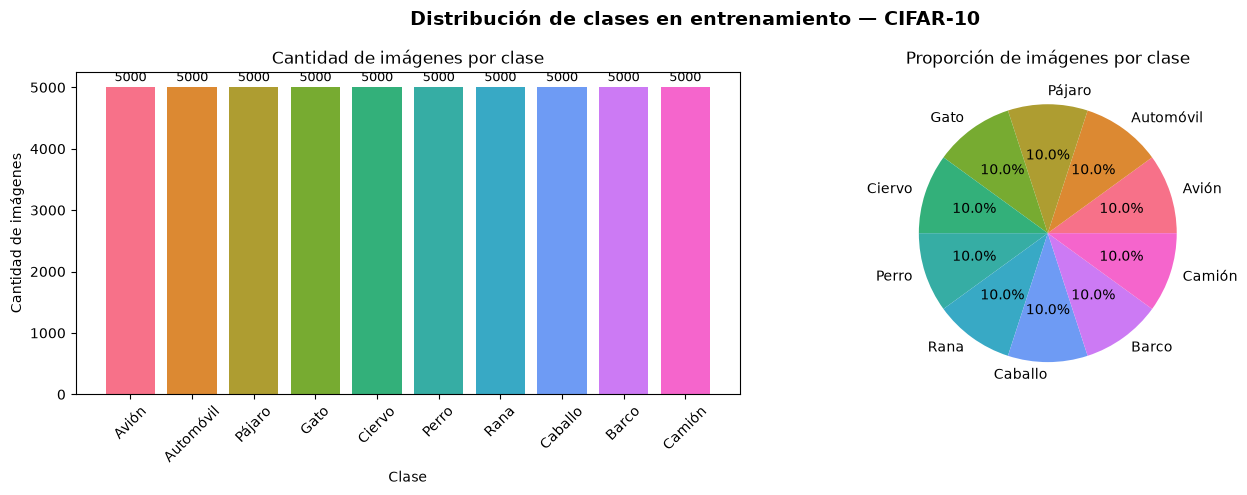


Resumen de la distribución de clases:
Avión          : 5000 imágenes (10.0%)
Automóvil      : 5000 imágenes (10.0%)
Pájaro         : 5000 imágenes (10.0%)
Gato           : 5000 imágenes (10.0%)
Ciervo         : 5000 imágenes (10.0%)
Perro          : 5000 imágenes (10.0%)
Rana           : 5000 imágenes (10.0%)
Caballo        : 5000 imágenes (10.0%)
Barco          : 5000 imágenes (10.0%)
Camión         : 5000 imágenes (10.0%)


In [3]:
# Cuenta cuántas imágenes de entrenamiento hay en cada clase.
counts = np.bincount(y_train_full, minlength=len(class_names))
class_ids = np.arange(len(class_names))

# Crea dos visualizaciones para revisar la distribución.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Distribución de clases en entrenamiento — CIFAR-10",
    fontsize=14,
    fontweight="bold"
)

# Gráfico de barras
colors = sns.color_palette("husl", len(class_names))
axes[0].bar(class_names, counts, color=colors)
axes[0].set_title("Cantidad de imágenes por clase")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Cantidad de imágenes")
axes[0].tick_params(axis="x", rotation=45)

# Escribe el conteo encima de cada barra.
for i, count in enumerate(counts):
    axes[0].text(i, count + 100, str(count), ha="center", fontsize=9)

# Gráfico de proporciones
axes[1].pie(
    counts,
    labels=class_names,
    autopct="%1.1f%%",
    colors=colors
)
axes[1].set_title("Proporción de imágenes por clase")

plt.tight_layout()
plt.savefig("distribucion_clases.png", dpi=150, bbox_inches="tight")
plt.show()

# Muestra también los valores numéricos.
print("\nResumen de la distribución de clases:")
for class_id, name in zip(class_ids, class_names):
    percentage = counts[class_id] / len(y_train_full) * 100
    print(f"{name:<15}: {counts[class_id]} imágenes ({percentage:.1f}%)")

La distribución del conjunto de entrenamiento es uniforme: cada una de las diez clases contiene 5.000 imágenes (10% del total). Por ello, no se observa un desbalance entre clases que requiera ajustes específicos. De todas formas, evaluaremos Precision, Recall y F1-Score para revisar el rendimiento del modelo en cada clase.

#### Visualización de ejemplos por clase

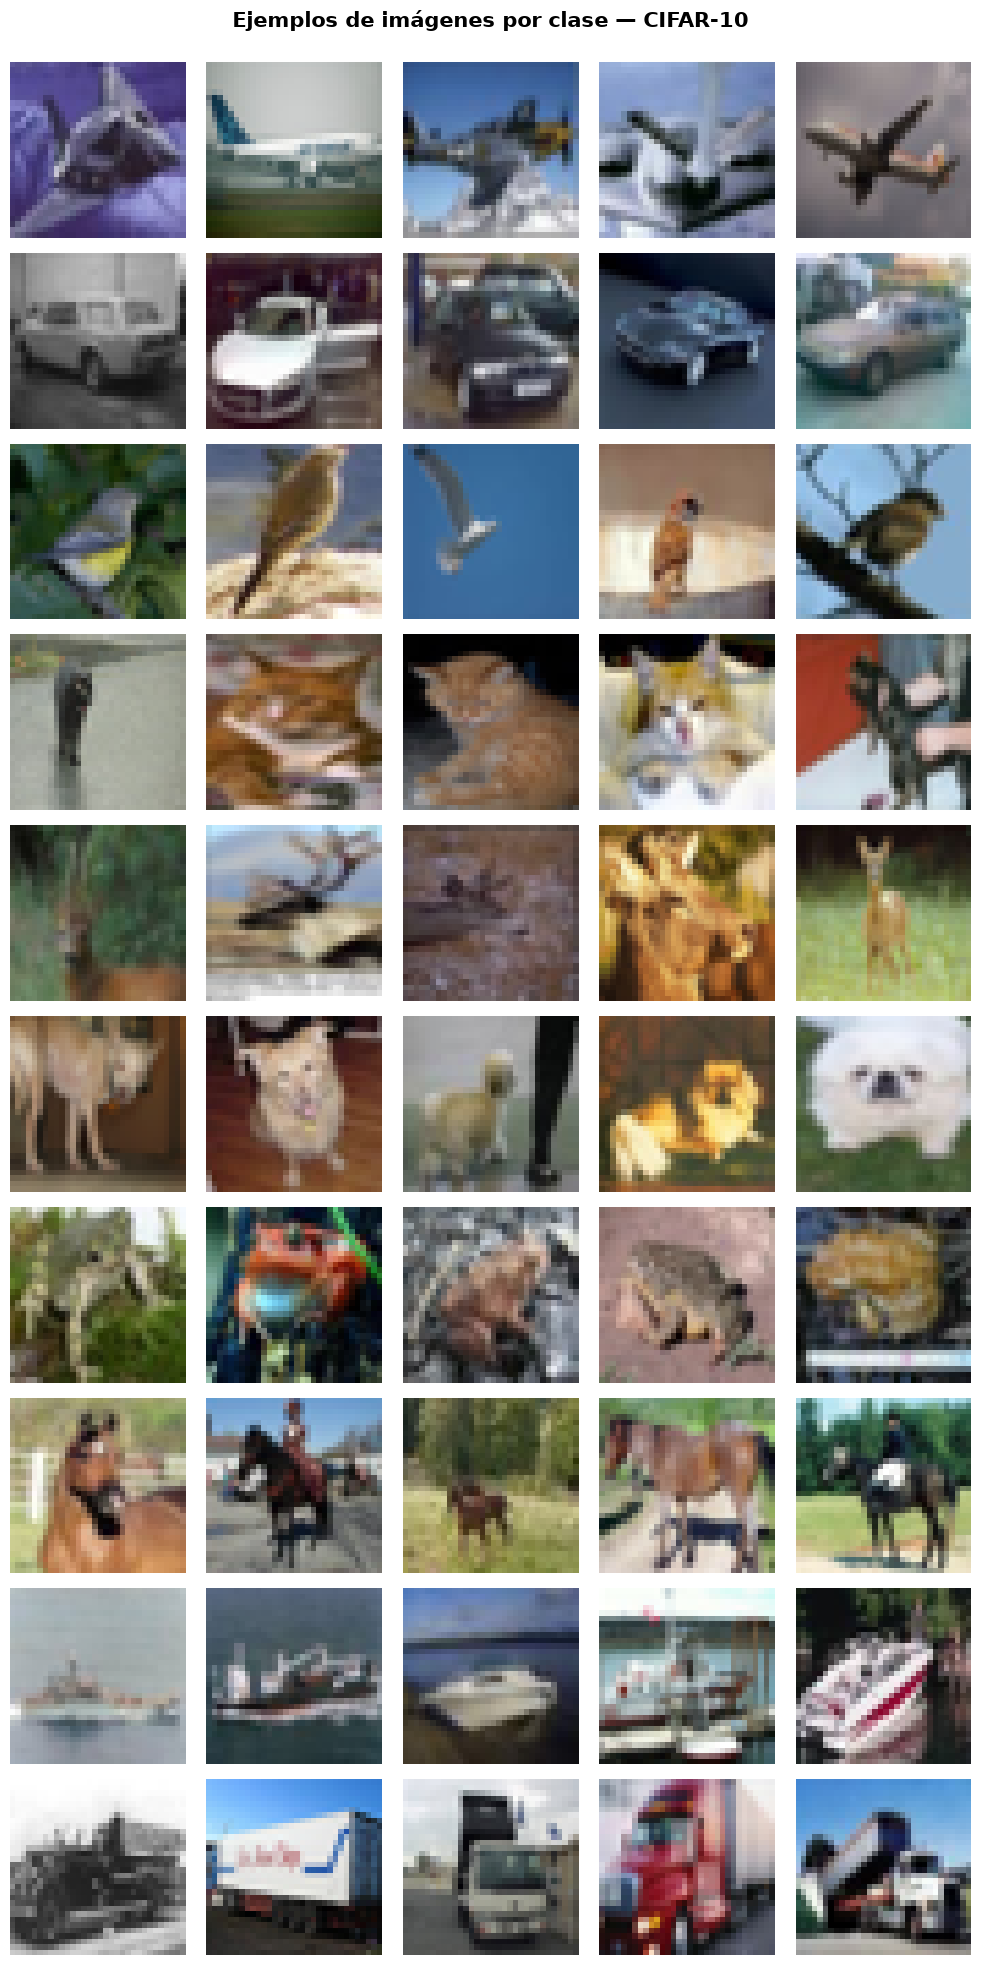

In [4]:
# Fija la semilla para que se elijan las mismas imágenes
# cada vez que ejecutes esta celda.
rng = np.random.default_rng(42)

fig, axes = plt.subplots(10, 5, figsize=(10, 20))
fig.suptitle(
    "Ejemplos de imágenes por clase — CIFAR-10",
    fontsize=15,
    fontweight="bold"
)

for class_id in range(10):
    # Busca las posiciones de las imágenes que pertenecen a esta clase.
    indices = np.where(y_train_full == class_id)[0]

    # Elige cinco imágenes distintas de esa clase.
    sample_indices = rng.choice(indices, 5, replace=False)

    for col, image_index in enumerate(sample_indices):
        axes[class_id, col].imshow(x_train_full[image_index])
        axes[class_id, col].axis("off")

        # Escribe el nombre de la clase al lado de la primera imagen de la fila.
        if col == 0:
            axes[class_id, col].set_ylabel(
                class_names[class_id],
                fontsize=11,
                rotation=0,
                labelpad=60,
                va="center"
            )

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("ejemplos_clases.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3 Normalización y Preprocesamiento


**¿Por qué dividir los datos?**

Separamos el conjunto original de entrenamiento en entrenamiento y validación. Usaremos los datos de entrenamiento para ajustar los parámetros del modelo y los de validación para comparar configuraciones durante los experimentos. El conjunto de prueba se mantiene reservado para la evaluación final.

**¿Por qué normalizar los píxeles?**

Los valores originales de los píxeles están entre 0 y 255. Los dividimos por 255 para transformarlos al rango de 0 a 1. Esto pone las entradas en una escala más manejable para el entrenamiento y puede ayudar a que la optimización sea más estable.

**¿Por qué aplanar las imágenes?**

El modelo MLP recibe vectores de características. Cada imagen tiene 32 × 32 píxeles y 3 canales de color, es decir, 3.072 valores. Por eso convertimos cada imagen en un vector de 3.072 elementos antes de ingresarla al MLP. Al aplanarla, la red deja de recibir explícitamente la distribución espacial de los píxeles.
Después de este texto, incluye el código que divide entrenamiento y validación, normaliza los píxeles y aplana las imágenes.

       RESULTADO DEL PREPROCESAMIENTO
Entrenamiento original : (45000, 32, 32, 3)
Entrenamiento preparado: (45000, 3072)
Validación original    : (5000, 32, 32, 3)
Validación preparada   : (5000, 3072)
Prueba original        : (10000, 32, 32, 3)
Prueba preparada       : (10000, 3072)
Rango normalizado      : [0.0 - 1.0]


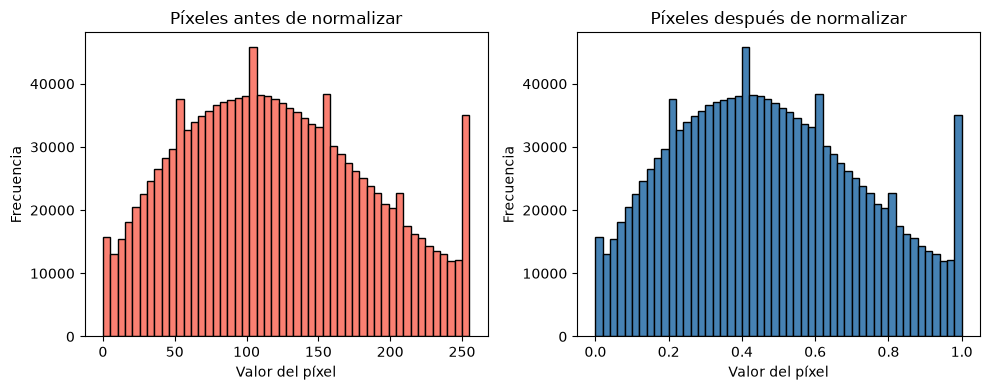

In [5]:
# Separa el conjunto original de entrenamiento en entrenamiento y validación.
# stratify mantiene la proporción de las clases en ambos grupos.
x_train_raw, x_val_raw, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.10,
    random_state=42,
    stratify=y_train_full
)

# Conserva las imágenes de prueba originales para compararlas luego.
x_test_raw = x_test

# Aplana las imágenes y normaliza los píxeles de [0, 255] a [0, 1].
x_train = x_train_raw.reshape(len(x_train_raw), -1).astype("float32") / 255.0
x_val = x_val_raw.reshape(len(x_val_raw), -1).astype("float32") / 255.0
x_test = x_test_raw.reshape(len(x_test_raw), -1).astype("float32") / 255.0

print("=" * 50)
print("       RESULTADO DEL PREPROCESAMIENTO")
print("=" * 50)
print(f"Entrenamiento original : {x_train_raw.shape}")
print(f"Entrenamiento preparado: {x_train.shape}")
print(f"Validación original    : {x_val_raw.shape}")
print(f"Validación preparada   : {x_val.shape}")
print(f"Prueba original        : {x_test_raw.shape}")
print(f"Prueba preparada       : {x_test.shape}")
print(f"Rango normalizado      : [{x_train.min():.1f} - {x_train.max():.1f}]")
print("=" * 50)

# Compara los valores de píxel antes y después de normalizar.
# Se toma cada centésimo valor para hacer el gráfico más liviano.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(
    x_train_raw.ravel()[::100],
    bins=50,
    color="salmon",
    edgecolor="black"
)
axes[0].set_title("Píxeles antes de normalizar")
axes[0].set_xlabel("Valor del píxel")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(
    x_train.ravel()[::100],
    bins=50,
    color="steelblue",
    edgecolor="black"
)
axes[1].set_title("Píxeles después de normalizar")
axes[1].set_xlabel("Valor del píxel")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.savefig("normalizacion.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.4 Resultado
Resumen del análisis y preprocesamiento
- Distribución de clases: el conjunto de entrenamiento contiene 5.000 imágenes por cada clase, equivalente al 10% del total. No se observa desbalance en la cantidad de ejemplos por clase.
- Normalización: los valores de los píxeles se transformaron del rango [0, 255] al rango [0, 1]. Esta escala facilita el trabajo del optimizador durante el entrenamiento.
- Aplanamiento: cada imagen de 32 × 32 × 3 se convirtió en un vector de 3.072 valores, formato que recibe el MLP.



---
# 3. Definición del Modelo MLP

### 3.1 por qué un MLP?
La evaluación solicita implementar una red neuronal artificial multicapa para resolver un problema de clasificación. Por eso, utilizaremos un MLP (Multilayer Perceptron) con CIFAR-10.
Un MLP conecta cada neurona de una capa con las neuronas de la capa siguiente. Las funciones de activación no lineales permiten que la red aprenda relaciones más complejas que las que aprendería un perceptrón simple. En este proyecto, las imágenes se aplanan a vectores de 3.072 valores antes de ingresarlas al modelo.
Aunque un MLP permite aplicar y estudiar los conceptos de la evaluación, al aplanar las imágenes se pierde la disposición espacial de los píxeles. Por eso, no aprovecharemos directamente la relación entre píxeles vecinos.

### 3.2 Arquitectura inicial
Como configuración inicial, probaremos una arquitectura con tres capas densas ocultas de 512, 256 y 128 neuronas. La capa de entrada recibe los 3.072 valores de cada imagen y la capa de salida tiene 10 neuronas, una por cada clase de CIFAR-10. Usaremos ReLU en las capas ocultas como punto de partida y softmax en la capa de salida para obtener una probabilidad por clase. La pérdida inicial será Sparse Categorical Crossentropy, compatible con las etiquetas enteras de CIFAR-10, y comenzaremos con Adam y una tasa de aprendizaje de 0.001. Estos valores forman nuestra configuración base; su efecto se evaluará experimentalmente. Más adelante compararemos activaciones, funciones de pérdida, tasa de aprendizaje, tamaño del batch y técnicas de regularización mediante experimentos controlados.
**Para evaluar el efecto de Dropout, compararemos esta arquitectura base sin Dropout con una segunda versión que incorporará Dropout de 0.3 después de cada capa oculta. Mantendremos los demás parámetros iguales durante esta comparación, de modo que podamos atribuir las diferencias observadas al uso de Dropout.**


### 3.3 Resumen de la arquitectura base
| Parte | capa | Neuronas | Activación | Justificación |
|------|------|----------|------------|---------------|
| Entrada | Vector aplanado | 3.072 valores| — | Corresponde a los valores de píxel de una imagen de 32 × 32 × 3. |
| Oculta 1 | Dense | 512 | ReLU | Primera capa de la configuración base; su capacidad se evaluará durante el entrenamiento. |
| Oculta 2 | Dense | 256 | ReLU | Capa intermedia para transformar la representación aprendida por la capa anterior. |
| Oculta 3 | Dense | 128 | ReLU | Última capa oculta antes de clasificar. |
| Salida | Dense | 10 | Softmax |Produce una salida para cada clase de CIFAR-10. |




### 3.4 Limitación del MLP para imágenes
El MLP recibe cada imagen como un vector y no conserva explícitamente su estructura de alto, ancho y canales. Por ello, no aprovecha directamente las relaciones espaciales entre píxeles vecinos. Una CNN está diseñada para imágenes y podría ser más adecuada para este tipo de datos, pero esta evaluación requiere implementar un MLP. Consideraremos esta característica al interpretar los resultados y las limitaciones del modelo.

#### Definición del modelo MLP

In [6]:
def construir_modelo(input_dim=3072, dropout_rate=0.0, learning_rate=0.001):
    """Construye y compila un MLP para clasificar CIFAR-10."""

    capas_modelo = [
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation="relu")
    ]

    # Agrega Dropout solo si la tasa es mayor que cero.
    if dropout_rate > 0:
        capas_modelo.append(layers.Dropout(dropout_rate))

    capas_modelo.append(layers.Dense(256, activation="relu"))

    if dropout_rate > 0:
        capas_modelo.append(layers.Dropout(dropout_rate))

    capas_modelo.append(layers.Dense(128, activation="relu"))

    if dropout_rate > 0:
        capas_modelo.append(layers.Dropout(dropout_rate))

    capas_modelo.append(layers.Dense(10, activation="softmax"))

    model = models.Sequential(capas_modelo)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Modelo base: no contiene capas Dropout
modelo_base = construir_modelo(dropout_rate=0.0)

# Modelo experimental: usa Dropout del 30%
modelo_dropout = construir_modelo(dropout_rate=0.3)

print("MODELO BASE — SIN DROPOUT")
modelo_base.summary()

print("\nMODELO CON DROPOUT DEL 30%")
modelo_dropout.summary()

MODELO BASE — SIN DROPOUT


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

#### Visualización de la arquitectura MLP

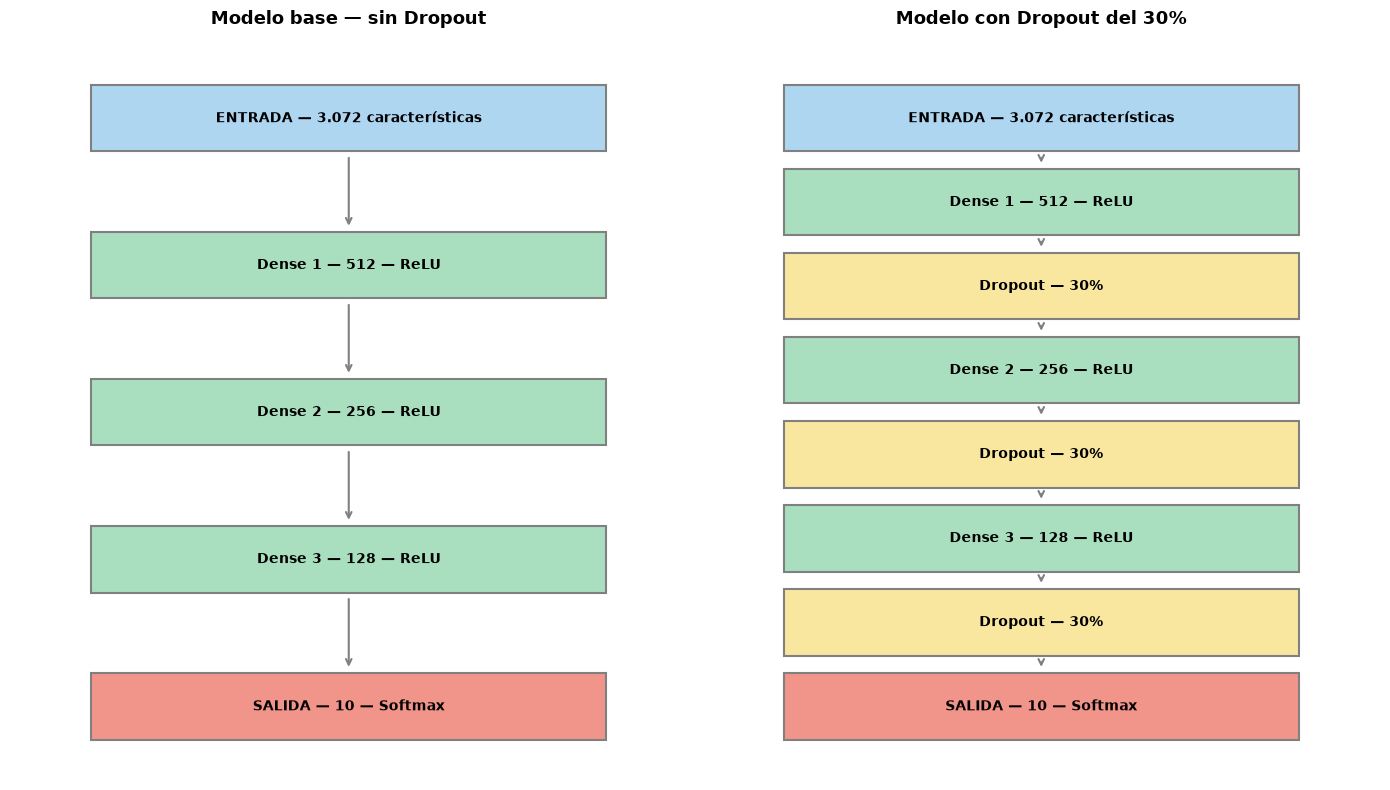

Parámetros del modelo base: 1,738,890
Parámetros del modelo con Dropout: 1,738,890


In [7]:
def dibujar_arquitectura(ax, capas, titulo):
    ax.axis("off")

    # Distribuye las capas verticalmente.
    y_superior = 0.90
    y_inferior = 0.10
    posiciones_y = np.linspace(y_superior, y_inferior, len(capas))

    for i, ((nombre, detalle, color), y) in enumerate(zip(capas, posiciones_y)):
        rect = plt.Rectangle(
            (0.12, y - 0.045),
            0.76,
            0.09,
            facecolor=color,
            edgecolor="gray",
            linewidth=1.5,
            transform=ax.transAxes,
            zorder=2
        )
        ax.add_patch(rect)

        ax.text(
            0.50,
            y,
            f"{nombre} — {detalle}",
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            transform=ax.transAxes
        )

        # Conecta cada capa con la siguiente.
        if i < len(capas) - 1:
            y_siguiente = posiciones_y[i + 1]
            ax.annotate(
                "",
                xy=(0.50, y_siguiente + 0.05),
                xytext=(0.50, y - 0.05),
                xycoords="axes fraction",
                arrowprops=dict(arrowstyle="->", color="gray", linewidth=1.5)
            )

    ax.set_title(titulo, fontsize=13, fontweight="bold", pad=15)


# Arquitectura base: sin Dropout
capas_base = [
    ("ENTRADA", "3.072 características", "#AED6F1"),
    ("Dense 1", "512 — ReLU", "#A9DFBF"),
    ("Dense 2", "256 — ReLU", "#A9DFBF"),
    ("Dense 3", "128 — ReLU", "#A9DFBF"),
    ("SALIDA", "10 — Softmax", "#F1948A")
]

# Arquitectura experimental: con Dropout del 30%
capas_dropout = [
    ("ENTRADA", "3.072 características", "#AED6F1"),
    ("Dense 1", "512 — ReLU", "#A9DFBF"),
    ("Dropout", "30%", "#F9E79F"),
    ("Dense 2", "256 — ReLU", "#A9DFBF"),
    ("Dropout", "30%", "#F9E79F"),
    ("Dense 3", "128 — ReLU", "#A9DFBF"),
    ("Dropout", "30%", "#F9E79F"),
    ("SALIDA", "10 — Softmax", "#F1948A")
]

# Dibuja ambas arquitecturas una al lado de la otra.
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

dibujar_arquitectura(
    axes[0],
    capas_base,
    "Modelo base — sin Dropout"
)

dibujar_arquitectura(
    axes[1],
    capas_dropout,
    "Modelo con Dropout del 30%"
)

plt.tight_layout()
plt.savefig("arquitectura_mlp.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Parámetros del modelo base: {modelo_base.count_params():,}")
print(f"Parámetros del modelo con Dropout: {modelo_dropout.count_params():,}")

#### 3.5 Resumen de las arquitecturas iniciales
Se construyeron dos versiones de la arquitectura MLP para comparar el efecto de Dropout. Ambas tienen tres capas ocultas Dense con 512, 256 y 128 neuronas, y una capa de salida con 10 neuronas para las clases de CIFAR-10.
Cada versión tiene 1.738.890 parámetros entrenables. La primera capa Dense concentra la mayor cantidad, con 1.573.376 parámetros, porque recibe los 3.072 valores de cada imagen. Las capas Dropout no añaden parámetros entrenables: durante el entrenamiento, desactivan aleatoriamente una proporción de activaciones.
El modelo base no utiliza Dropout. La segunda versión aplica Dropout del 30% después de cada capa oculta. Ambos modelos están compilados con Adam, una tasa de aprendizaje inicial de 0.001 y Sparse Categorical Crossentropy, compatible con las etiquetas enteras de CIFAR-10.
Estos modelos representan las configuraciones iniciales del experimento. Su desempeño se comparará después del entrenamiento usando los datos de validación; con esos resultados se decidirá qué configuración utilizar en la evaluación final.

---
# 4. Entrenamiento del Modelo

### 4.1 Hiperparámetros de entrenamiento base

| Hiperparámetro | Valor Inicial| Justificación |
|---|---|---|
| **Épocas** | 30 máximmo | Es el límite inicial de entrenamiento. Revisaremos las curvas de entrenamiento y validación para detectar si conviene detenernos antes o probar otra cantidad.ientes para converger sin sobreentrenar |
| **Batch size** | 64 | Punto de partida para actualizar los parámetros usando grupos de imágenes. Compararemos otros tamaños más adelante. |
| **Learning rate** | 0.001 | Valor inicial para Adam. Evaluaremos su efecto en experimentos controlados. |
| **Optimizer** | Adam | Configuración inicial para actualizar los pesos a partir de los gradientes. También se puede comparar con otro optimizador. |
| **Función de perdida** | Sparse Categorical Crossentropy| CAdecuada para clasificación multiclase con etiquetas enteras de 0 a 9. |
| **Validation split** | 5.000 imágenes (10% del entrenamiento original)| Ya quedó separada en la sección 2.3 y se usará para comparar el desempeño durante el entrenamiento. |

### 4.2 ¿Qué es Backpropagation?
Durante el entrenamiento, el modelo realiza primero una propagación hacia adelante (forward pass): recibe una imagen, calcula una predicción y la compara con su etiqueta mediante la función de pérdida.
Después, la retropropagación (backpropagation) calcula cómo contribuyeron los pesos de la red al error, propagando los gradientes desde la salida hacia las capas anteriores. El optimizador Adam utiliza esos gradientes para actualizar los pesos y reducir la pérdida.
Este proceso se repite en cada batch y durante las épocas de entrenamiento. En la versión con Dropout, algunas activaciones se desactivan aleatoriamente durante el entrenamiento; durante la evaluación, Dropout no las desactiva.

#### Entrenamiento del modelo base

In [8]:
import time
from tensorflow.keras.callbacks import EarlyStopping

# Detiene el entrenamiento si la pérdida de validación
# no mejora durante 5 épocas consecutivas.
early_stopping_base = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("Iniciando entrenamiento del modelo base...")
print("=" * 55)

inicio = time.time()

historial_base = modelo_base.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping_base],
    verbose=1
)

tiempo_total_base = time.time() - inicio

print("=" * 55)
print(f"Entrenamiento completado en {tiempo_total_base:.1f} segundos")
print(f"Épocas ejecutadas: {len(historial_base.history['accuracy'])}")

Iniciando entrenamiento del modelo base...
Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3214 - loss: 1.8782 - val_accuracy: 0.3454 - val_loss: 1.8396
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3901 - loss: 1.6949 - val_accuracy: 0.3688 - val_loss: 1.7895
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4214 - loss: 1.6094 - val_accuracy: 0.3940 - val_loss: 1.7000
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4457 - loss: 1.5524 - val_accuracy: 0.4406 - val_loss: 1.5689
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4597 - loss: 1.5042 - val_accuracy: 0.4412 - val_loss: 1.5632
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4776 - loss: 1.4665 - val_accuracy: 0.4468 - val_loss: 1.5673
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4874 - loss: 1.4353 - val_accuracy: 0.4608 - val_loss: 1.5158
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accurac

#### 4.3 Curva de aprendizaje

###### Entrenamiento del modelo base

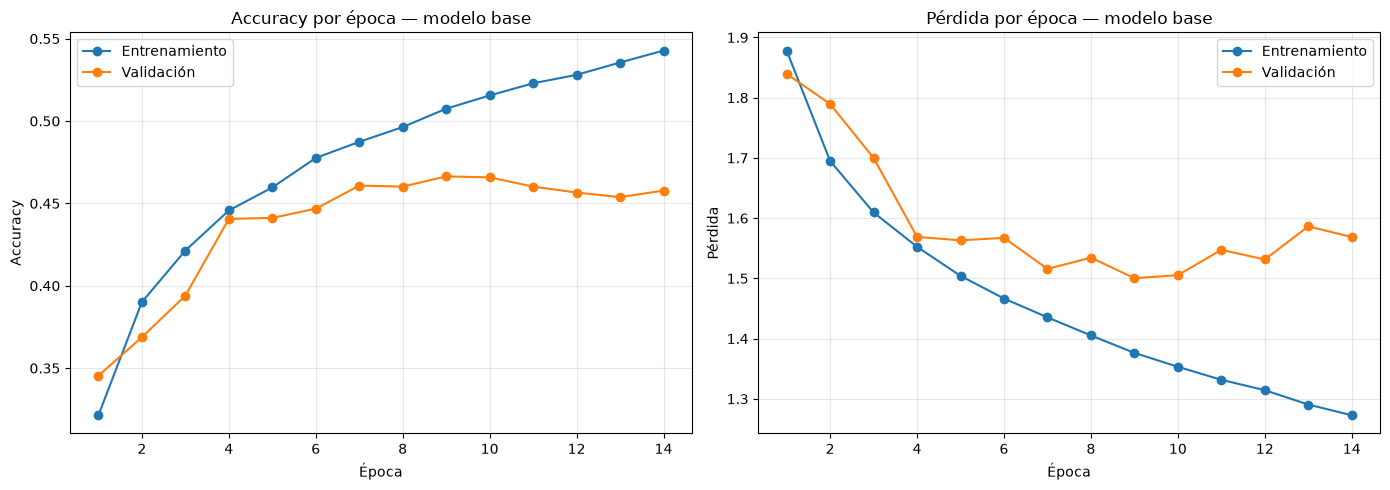


     MEJORES RESULTADOS — MODELO BASE
Mejor época según val_loss: 9
Train Accuracy: 0.5075 (50.75%)
Val Accuracy  : 0.4664 (46.64%)
Train Loss    : 1.3763
Val Loss      : 1.5004

Diferencia entre accuracy de entrenamiento y validación: 0.0411 (4.11 puntos porcentuales)
Diagnóstico: hay señales de sobreajuste después de la mejor época; EarlyStopping restauró los pesos de la época con menor val_loss.


In [9]:
# Número de épocas registradas durante el entrenamiento
epocas = range(1, len(historial_base.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de accuracy
axes[0].plot(
    epocas,
    historial_base.history["accuracy"],
    marker="o",
    label="Entrenamiento"
)
axes[0].plot(
    epocas,
    historial_base.history["val_accuracy"],
    marker="o",
    label="Validación"
)
axes[0].set_title("Accuracy por época — modelo base")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Curva de pérdida
axes[1].plot(
    epocas,
    historial_base.history["loss"],
    marker="o",
    label="Entrenamiento"
)
axes[1].plot(
    epocas,
    historial_base.history["val_loss"],
    marker="o",
    label="Validación"
)
axes[1].set_title("Pérdida por época — modelo base")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Pérdida")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("curva_aprendizaje_modelo_base.png", dpi=150, bbox_inches="tight")
plt.show()
# Encuentra la época con menor pérdida de validación.
mejor_indice = np.argmin(historial_base.history["val_loss"])
mejor_epoca = mejor_indice + 1

# Recupera las métricas registradas en esa época.
train_acc_final = historial_base.history["accuracy"][mejor_indice]
val_acc_final = historial_base.history["val_accuracy"][mejor_indice]
train_loss_final = historial_base.history["loss"][mejor_indice]
val_loss_final = historial_base.history["val_loss"][mejor_indice]

print("\n" + "=" * 50)
print("     MEJORES RESULTADOS — MODELO BASE")
print("=" * 50)
print(f"Mejor época según val_loss: {mejor_epoca}")
print(f"Train Accuracy: {train_acc_final:.4f} ({train_acc_final * 100:.2f}%)")
print(f"Val Accuracy  : {val_acc_final:.4f} ({val_acc_final * 100:.2f}%)")
print(f"Train Loss    : {train_loss_final:.4f}")
print(f"Val Loss      : {val_loss_final:.4f}")
print("=" * 50)

diferencia = train_acc_final - val_acc_final
print(f"\nDiferencia entre accuracy de entrenamiento y validación: "
      f"{diferencia:.4f} ({diferencia * 100:.2f} puntos porcentuales)")

# Revisa si después de la mejor época siguió bajando la pérdida
# de entrenamiento mientras subía la de validación.
if (
    mejor_indice < len(historial_base.history["val_loss"]) - 1
    and historial_base.history["loss"][-1] < train_loss_final
    and historial_base.history["val_loss"][-1] > val_loss_final
):
    print(
        "Diagnóstico: hay señales de sobreajuste después de la mejor época; "
        "EarlyStopping restauró los pesos de la época con menor val_loss."
    )
else:
    print(
        "Diagnóstico: interpreta la diferencia junto con las curvas de "
        "entrenamiento y validación antes de concluir si hay sobreajuste."
    )

######  Entrenamiento del modelo con Dropout

In [10]:
import time
from tensorflow.keras.callbacks import EarlyStopping

# Construye un modelo nuevo con Dropout del 30%.
modelo_dropout = construir_modelo(
    dropout_rate=0.3,
    learning_rate=0.001
)

# Callback independiente para el modelo con Dropout.
early_stopping_dropout = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("Iniciando entrenamiento del modelo con Dropout...")
print("=" * 55)

inicio_dropout = time.time()

historial_dropout = modelo_dropout.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping_dropout],
    verbose=1
)

tiempo_total_dropout = time.time() - inicio_dropout

# Obtiene las métricas de la época con menor pérdida de validación.
mejor_indice_dropout = np.argmin(historial_dropout.history["val_loss"])
mejor_epoca_dropout = mejor_indice_dropout + 1

train_acc_dropout = historial_dropout.history["accuracy"][mejor_indice_dropout]
val_acc_dropout = historial_dropout.history["val_accuracy"][mejor_indice_dropout]
train_loss_dropout = historial_dropout.history["loss"][mejor_indice_dropout]
val_loss_dropout = historial_dropout.history["val_loss"][mejor_indice_dropout]

print("=" * 55)
print(f"Entrenamiento completado en {tiempo_total_dropout:.1f} segundos")
print(f"Épocas ejecutadas: {len(historial_dropout.history['accuracy'])}")

print("\n" + "=" * 50)
print("     MEJORES RESULTADOS — MODELO CON DROPOUT")
print("=" * 50)
print(f"Mejor época según val_loss: {mejor_epoca_dropout}")
print(f"Train Accuracy: {train_acc_dropout:.4f} ({train_acc_dropout * 100:.2f}%)")
print(f"Val Accuracy  : {val_acc_dropout:.4f} ({val_acc_dropout * 100:.2f}%)")
print(f"Train Loss    : {train_loss_dropout:.4f}")
print(f"Val Loss      : {val_loss_dropout:.4f}")
print(f"Tiempo        : {tiempo_total_dropout:.1f} segundos")
print("=" * 50)

Iniciando entrenamiento del modelo con Dropout...
Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2015 - loss: 2.1104 - val_accuracy: 0.2752 - val_loss: 1.9401
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2484 - loss: 1.9825 - val_accuracy: 0.2808 - val_loss: 1.8974
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.2650 - loss: 1.9549 - val_accuracy: 0.2976 - val_loss: 1.8694
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2739 - loss: 1.9305 - val_accuracy: 0.2914 - val_loss: 1.8753
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2843 - loss: 1.9150 - val_accuracy: 0.3114 - val_loss: 1.8524
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2919 - loss: 1.8976 - val_accuracy: 0.3242 - val_loss: 1.8462
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3014 - loss: 1.8896 - val_accuracy: 0.3172 - val_loss: 1.8646
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - 

######Gráficos comparativos de accuracy y pérdida

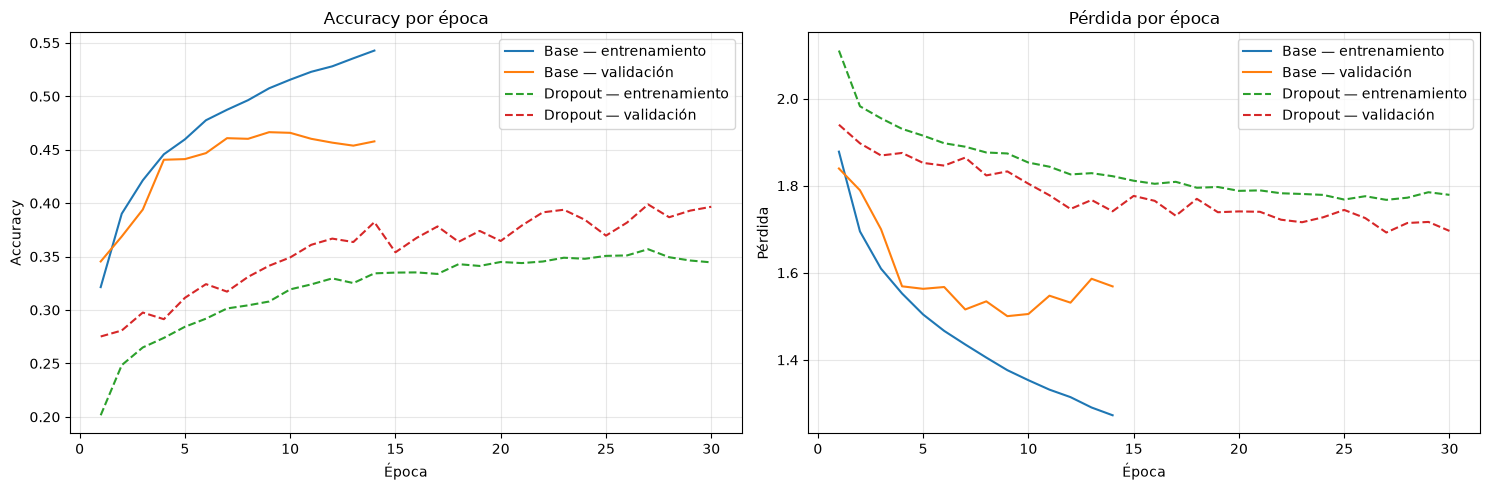

,Modelo,Mejor época,Train Accuracy,Val Accuracy,Train Loss,Val Loss
0,Base sin Dropout,9,0.5075,0.4664,1.3763,1.5004
1,Dropout 30%,27,0.3569,0.3988,1.7675,1.6925


In [11]:
# Eje de épocas para cada entrenamiento
epocas_base = range(1, len(historial_base.history["loss"]) + 1)
epocas_dropout = range(1, len(historial_dropout.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Comparación de accuracy
axes[0].plot(
    epocas_base,
    historial_base.history["accuracy"],
    label="Base — entrenamiento"
)
axes[0].plot(
    epocas_base,
    historial_base.history["val_accuracy"],
    label="Base — validación"
)
axes[0].plot(
    epocas_dropout,
    historial_dropout.history["accuracy"],
    linestyle="--",
    label="Dropout — entrenamiento"
)
axes[0].plot(
    epocas_dropout,
    historial_dropout.history["val_accuracy"],
    linestyle="--",
    label="Dropout — validación"
)
axes[0].set_title("Accuracy por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Comparación de pérdida
axes[1].plot(
    epocas_base,
    historial_base.history["loss"],
    label="Base — entrenamiento"
)
axes[1].plot(
    epocas_base,
    historial_base.history["val_loss"],
    label="Base — validación"
)
axes[1].plot(
    epocas_dropout,
    historial_dropout.history["loss"],
    linestyle="--",
    label="Dropout — entrenamiento"
)
axes[1].plot(
    epocas_dropout,
    historial_dropout.history["val_loss"],
    linestyle="--",
    label="Dropout — validación"
)
axes[1].set_title("Pérdida por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Pérdida")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("comparacion_curvas_base_dropout.png", dpi=150, bbox_inches="tight")
plt.show()


# Tabla comparativa usando, para cada modelo,
# la época con menor pérdida de validación.
indice_base = np.argmin(historial_base.history["val_loss"])
indice_dropout = np.argmin(historial_dropout.history["val_loss"])

comparacion = pd.DataFrame({
    "Modelo": ["Base sin Dropout", "Dropout 30%"],
    "Mejor época": [indice_base + 1, indice_dropout + 1],
    "Train Accuracy": [
        historial_base.history["accuracy"][indice_base],
        historial_dropout.history["accuracy"][indice_dropout]
    ],
    "Val Accuracy": [
        historial_base.history["val_accuracy"][indice_base],
        historial_dropout.history["val_accuracy"][indice_dropout]
    ],
    "Train Loss": [
        historial_base.history["loss"][indice_base],
        historial_dropout.history["loss"][indice_dropout]
    ],
    "Val Loss": [
        historial_base.history["val_loss"][indice_base],
        historial_dropout.history["val_loss"][indice_dropout]
    ]
})

display(comparacion.round(4))

###### 4.3 Análisis de Resultados

En esta ejecución, el modelo base sin Dropout obtuvo el mejor resultado de validación: accuracy de 49,62 % y pérdida de 1,4362. El modelo con Dropout del 10 % tuvo un desempeño cercano, con accuracy de 48,98 % y pérdida de 1,4460. La diferencia entre ambos fue pequeña, pero el Dropout del 10 % no superó al modelo base.
El modelo con Dropout del 30 % obtuvo resultados inferiores, con accuracy de validación de 37,88 % y pérdida de 1,7621. En esta prueba, esa configuración no mejoró el desempeño y pudo limitar el aprendizaje del modelo.
La diferencia entre accuracy de entrenamiento y validación fue de 6,56 puntos porcentuales para el modelo base y de 0,06 puntos para el modelo con Dropout del 10 %. Esto sugiere que el Dropout del 10 % redujo la brecha entre entrenamiento y validación, aunque su resultado de validación fue ligeramente inferior al del modelo base. Por ahora, el modelo base es la mejor referencia de esta comparación. Estas conclusiones corresponden a esta ejecución; los resultados pueden variar al volver a entrenar los modelos.

###### Comparación de modelos con distintas tasas de Dropout

In [12]:
c

NameError: name 'c' is not defined

Análisis: El modelo base obtuvo el mejor resultado de validación: accuracy de 49,62 % y pérdida de 1,4362, en la época 16. El modelo con Dropout al 10 % fue muy cercano, con accuracy de 48,98 % y pérdida de 1,4460, en la época 23. El modelo con Dropout al 30 % rindió menos, con accuracy de 37,88 % y pérdida de 1,7621, en la época 14. En esta ejecución, el Dropout al 10 % se acercó al modelo base, pero no lo superó; la tasa del 30 % pudo ser excesiva para esta arquitectura. Seleccionamos el modelo base como referencia para los siguientes experimentos.

---
## 5. Backpropagation

### 5.1 ¿Qué es Backpropagation?
El entrenamiento de la red se realiza en dos fases que se repiten para cada lote (batch) de imágenes. En nuestro caso, cada imagen CIFAR-10 se representa como un vector de 3.072 valores.
Fase 1 — Propagación hacia adelante (forward pass)
1. El lote de imágenes entra a la red.
2. Cada capa densa calcula una transformación lineal: \(Z = XW + b\).
3. Las capas ocultas aplican ReLU: \(A = \max(0,Z)\).
4. La capa de salida aplica softmax para producir una probabilidad para cada una de las 10 clases.
5. Se compara la predicción con la etiqueta correcta usando Sparse Categorical Crossentropy. Esta función recibe las etiquetas como números enteros del 0 al 9.
Fase 2 — Retropropagación (backpropagation)
1. Se calcula cómo cambia la pérdida cuando cambian los pesos de la red; ese cambio se expresa mediante gradientes.
2. La regla de la cadena permite propagar esos gradientes desde la salida hacia las capas anteriores.
3. Adam usa los gradientes para actualizar los pesos y sesgos, buscando reducir la pérdida. Adam adapta las actualizaciones usando información acumulada de gradientes anteriores; por eso, su actualización no es simplemente \(W = W - lr \cdot \nabla W\).
4. El proceso se repite con los siguientes lotes hasta completar la época. Luego comienza otra época.
Keras realiza automáticamente la propagación hacia adelante, el cálculo de gradientes y las actualizaciones cuando ejecutamos modelo.fit().

### 5.2 Fórmulas
| Concepto | Fórmula | Descripción |
|---|---|---|
| Forward pass | Z = W·X + b | Combina las entradas con los pesos y sesgos |
| Activación ReLU | A = max(0, Z) | Introduce no linealidad en las capas ocultas |
| Activación Softmax | σ(z)ᵢ = eᶻⁱ / Σeᶻʲ | Convierte las salidas en probabilidades por clase|
| Loss Crossentropy | L = -Σ yᵢ·log(ŷᵢ) | Penaliza las predicciones que asignan poca probabilidad a la clase correcta |
| Actualización pesos | W = W - lr·∂L/∂W | Ajusta los pesos para reducir la pérdida |
| Gradiente| ∂L/∂W | Indica cómo cambia la pérdida al cambiar los pesos |

### 5.3 Rol en nuestro modelo
En cada lote, la retropropagación calcula los gradientes de los parámetros entrenables y Adam los usa para ajustar los pesos y sesgos. Así, el modelo va reduciendo el error de sus predicciones sobre las 10 clases de CIFAR-10. En nuestro trabajo observamos este aprendizaje mediante la pérdida y la exactitud (accuracy) de entrenamiento y validación.


#### Visualización de pérdida durante el entrenamiento


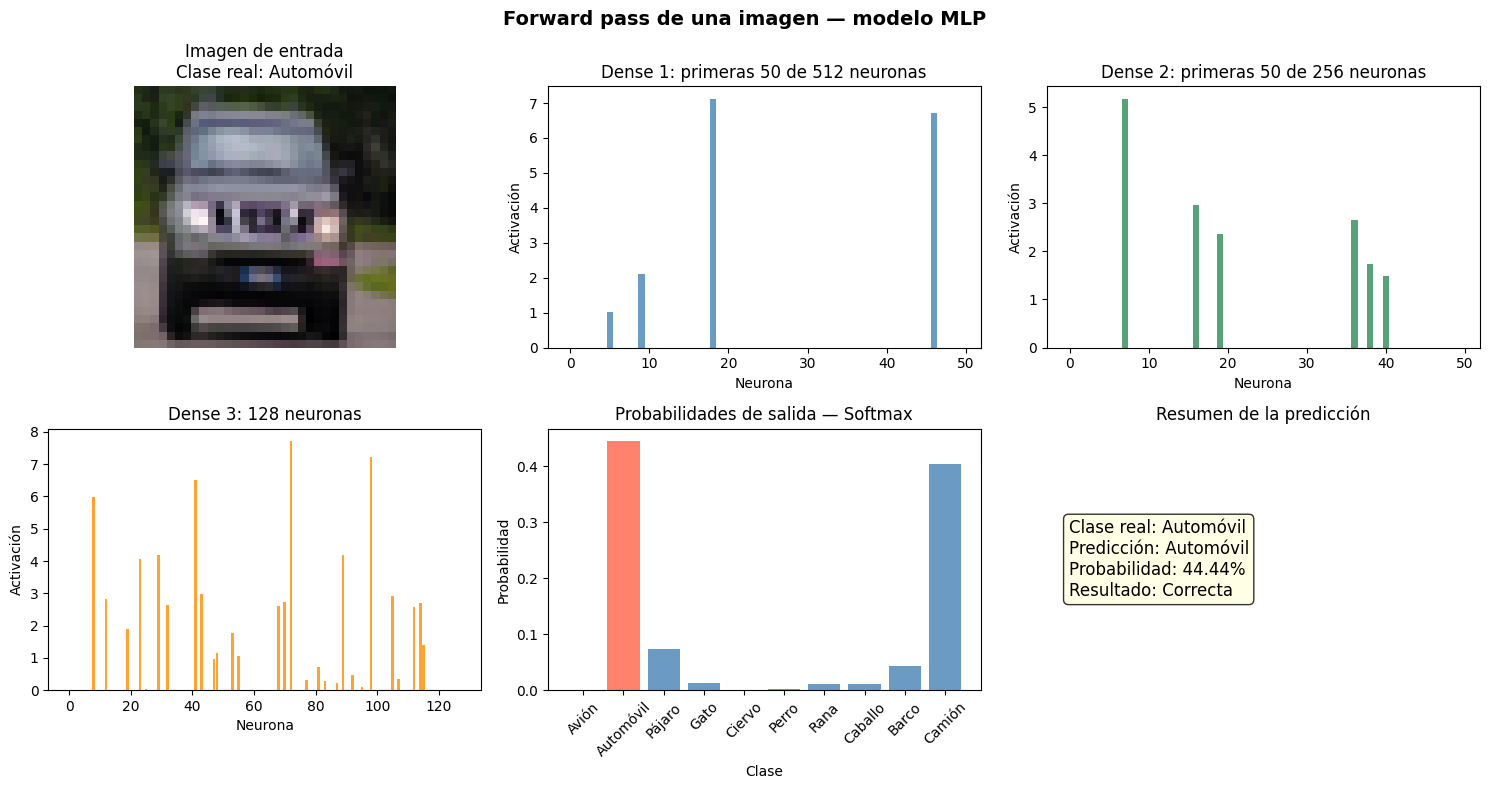

In [ ]:
from tensorflow.keras import Model

# Selecciona una imagen del conjunto de entrenamiento.
idx = 0
imagen_ejemplo = x_train[idx:idx + 1]
etiqueta_real = y_train[idx]

# Crea una entrada auxiliar y recorre el modelo capa por capa.
entrada_auxiliar = tf.keras.Input(shape=(3072,))
salida_actual = entrada_auxiliar
salidas_capas = []

for capa in modelo_base.layers:
    # Omite InputLayer si Keras la incluye en la lista.
    if isinstance(capa, tf.keras.layers.InputLayer):
        continue

    salida_actual = capa(salida_actual)
    salidas_capas.append(salida_actual)

# Modelo auxiliar que devuelve las activaciones de cada capa.
modelo_activaciones = Model(
    inputs=entrada_auxiliar,
    outputs=salidas_capas
)

# Ejecuta el forward pass.
activaciones = modelo_activaciones(imagen_ejemplo, training=False)
activaciones = [salida.numpy() for salida in activaciones]

# Reorganiza el vector de 3072 valores para mostrar la imagen.
imagen_para_grafico = imagen_ejemplo[0].reshape(32, 32, 3)

# Obtiene probabilidades y clase predicha.
probabilidades = activaciones[-1][0]
pred_clase = np.argmax(probabilidades)

# Prepara la figura.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(
    "Forward pass de una imagen — modelo MLP",
    fontsize=14,
    fontweight="bold"
)

# Imagen de entrada.
axes[0, 0].imshow(imagen_para_grafico)
axes[0, 0].set_title(
    f"Imagen de entrada\nClase real: {class_names[etiqueta_real]}"
)
axes[0, 0].axis("off")

# Activaciones de la primera capa densa: 512 neuronas.
axes[0, 1].bar(
    range(50),
    activaciones[0][0][:50],
    color="steelblue",
    alpha=0.8
)
axes[0, 1].set_title("Dense 1: primeras 50 de 512 neuronas")
axes[0, 1].set_xlabel("Neurona")
axes[0, 1].set_ylabel("Activación")

# Activaciones de la segunda capa densa: 256 neuronas.
axes[0, 2].bar(
    range(50),
    activaciones[1][0][:50],
    color="seagreen",
    alpha=0.8
)
axes[0, 2].set_title("Dense 2: primeras 50 de 256 neuronas")
axes[0, 2].set_xlabel("Neurona")
axes[0, 2].set_ylabel("Activación")

# Activaciones de la tercera capa densa: 128 neuronas.
axes[1, 0].bar(
    range(128),
    activaciones[2][0],
    color="darkorange",
    alpha=0.8
)
axes[1, 0].set_title("Dense 3: 128 neuronas")
axes[1, 0].set_xlabel("Neurona")
axes[1, 0].set_ylabel("Activación")

# Probabilidades de salida de las 10 clases.
colores = [
    "tomato" if i == pred_clase else "steelblue"
    for i in range(len(class_names))
]
axes[1, 1].bar(
    class_names,
    probabilidades,
    color=colores,
    alpha=0.8
)
axes[1, 1].set_title("Probabilidades de salida — Softmax")
axes[1, 1].set_xlabel("Clase")
axes[1, 1].set_ylabel("Probabilidad")
axes[1, 1].tick_params(axis="x", rotation=45)

# Compara la clase real con la predicción.
resultado = "Correcta" if pred_clase == etiqueta_real else "Incorrecta"
resumen = (
    f"Clase real: {class_names[etiqueta_real]}\n"
    f"Predicción: {class_names[pred_clase]}\n"
    f"Probabilidad: {probabilidades[pred_clase] * 100:.2f}%\n"
    f"Resultado: {resultado}"
)

axes[1, 2].text(
    0.05,
    0.5,
    resumen,
    fontsize=12,
    va="center",
    transform=axes[1, 2].transAxes,
    bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8)
)
axes[1, 2].axis("off")
axes[1, 2].set_title("Resumen de la predicción")

plt.tight_layout()
plt.savefig("forward_pass_modelo_base.png", dpi=150, bbox_inches="tight")
plt.show()

La imagen de ejemplo pertenece a la clase Automóvil. Durante el forward pass, las capas densas producen distintas activaciones y la capa Softmax asigna la mayor probabilidad a Automóvil (44,44 %). La predicción coincide con la etiqueta real, aunque la confianza del modelo es moderada.

Imagen de entrada: la imagen CIFAR-10 que se le entregó al modelo. Su etiqueta real es Automóvil.

Dense 1: muestra las activaciones de las primeras 50 de las 512 neuronas de la primera capa oculta. Cada barra representa cuánto se activó una neurona ante esa imagen.

Dense 2: muestra las primeras 50 activaciones de las 256 neuronas de la segunda capa.

Dense 3: muestra las activaciones de las 128 neuronas de la tercera capa.
Probabilidades de salida — Softmax: muestra la probabilidad que el modelo asigna a cada clase. Automóvil es la más alta, con 44,44 %; Camión le sigue de cerca. Por eso la predicción es correcta, pero el modelo tiene cierta duda.
Resumen de la predicción: indica la etiqueta real, la predicción, la probabilidad de la clase predicha y si acertó.

#### Evolución de la pérdida durante el entrenamiento

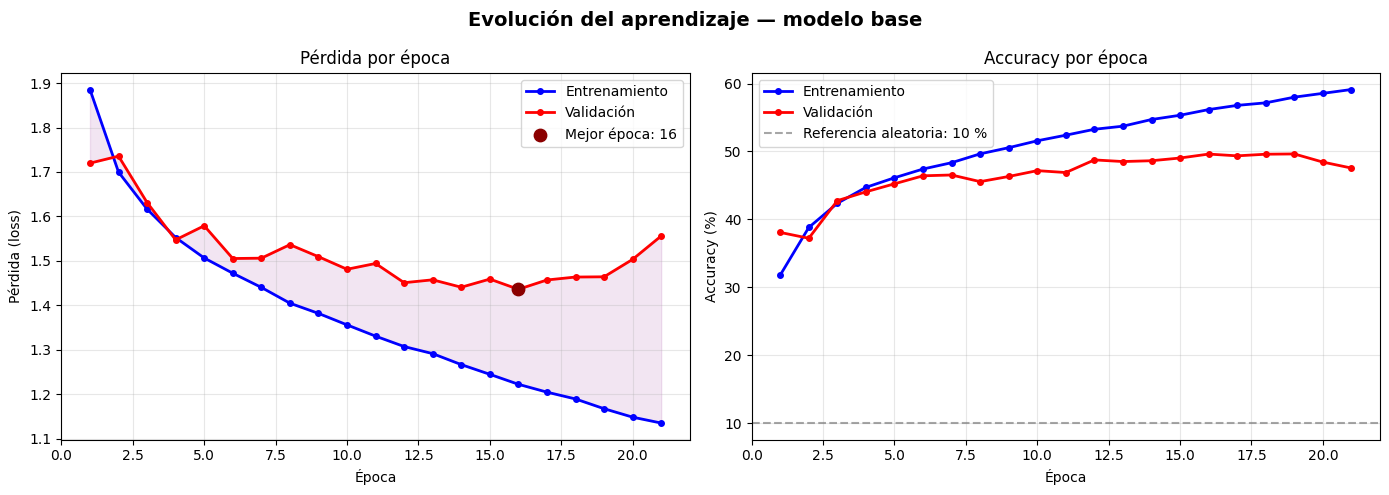


     RESUMEN DEL ENTRENAMIENTO — MODELO BASE
Épocas ejecutadas                 : 21
Mejor época según val_loss        : 16
Pérdida de entrenamiento inicial : 1.8854
Pérdida de entrenamiento final   : 1.1354
Menor pérdida de validación      : 1.4362
Accuracy de entrenamiento final  : 59.13%
Accuracy de validación en la mejor época: 49.62%


In [ ]:
# Historial del entrenamiento del modelo base.
hist = historial_base.history
epocas = np.arange(1, len(hist["loss"]) + 1)

# Encuentra la época con menor pérdida de validación.
mejor_indice = np.argmin(hist["val_loss"])
mejor_epoca = mejor_indice + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Evolución del aprendizaje — modelo base",
    fontsize=14,
    fontweight="bold"
)

# Pérdida de entrenamiento y validación.
axes[0].plot(
    epocas, hist["loss"],
    "b-o", linewidth=2, markersize=4,
    label="Entrenamiento"
)
axes[0].plot(
    epocas, hist["val_loss"],
    "r-o", linewidth=2, markersize=4,
    label="Validación"
)
axes[0].fill_between(
    epocas, hist["loss"], hist["val_loss"],
    alpha=0.1, color="purple"
)
axes[0].scatter(
    mejor_epoca, hist["val_loss"][mejor_indice],
    color="darkred", s=80, zorder=5,
    label=f"Mejor época: {mejor_epoca}"
)
axes[0].set_title("Pérdida por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Pérdida (loss)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy de entrenamiento y validación.
axes[1].plot(
    epocas, np.array(hist["accuracy"]) * 100,
    "b-o", linewidth=2, markersize=4,
    label="Entrenamiento"
)
axes[1].plot(
    epocas, np.array(hist["val_accuracy"]) * 100,
    "r-o", linewidth=2, markersize=4,
    label="Validación"
)
axes[1].axhline(
    y=10, color="gray", linestyle="--", alpha=0.7,
    label="Referencia aleatoria: 10 %"
)
axes[1].set_title("Accuracy por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("evolucion_entrenamiento_modelo_base.png",
            dpi=150, bbox_inches="tight")
plt.show()

# Resumen del entrenamiento.
print("\n" + "=" * 55)
print("     RESUMEN DEL ENTRENAMIENTO — MODELO BASE")
print("=" * 55)
print(f"Épocas ejecutadas                 : {len(epocas)}")
print(f"Mejor época según val_loss        : {mejor_epoca}")
print(f"Pérdida de entrenamiento inicial : {hist['loss'][0]:.4f}")
print(f"Pérdida de entrenamiento final   : {hist['loss'][-1]:.4f}")
print(f"Menor pérdida de validación      : {hist['val_loss'][mejor_indice]:.4f}")
print(f"Accuracy de entrenamiento final  : {hist['accuracy'][-1] * 100:.2f}%")
print(f"Accuracy de validación en la mejor época: "
      f"{hist['val_accuracy'][mejor_indice] * 100:.2f}%")
print("=" * 55)

### 5.4 Análisis del Backpropagation
Durante el entrenamiento, la pérdida del conjunto de entrenamiento disminuyó de 1,8854 a 1,1354, mientras que su accuracy final llegó a 59,13 %. Esto muestra que el modelo fue ajustando sus parámetros para aprender los datos de entrenamiento.
En validación, la menor pérdida fue 1,4362, alcanzada en la época 16. Después de ese punto, la pérdida de entrenamiento siguió bajando, pero la de validación tendió a subir y el accuracy de validación dejó de mejorar claramente. Esta diferencia sugiere sobreajuste: el modelo continuó aprendiendo los ejemplos de entrenamiento, pero eso no se tradujo en una mejora equivalente para datos no usados directamente para entrenarlo.
La exactitud de validación en la mejor época fue 49,62 %, superior a la referencia aleatoria del 10 % para diez clases. EarlyStopping detuvo el entrenamiento después de 21 épocas ejecutadas y restauró los pesos de la época con menor pérdida de validación (época 16). Esto permite conservar la versión que generalizó mejor según el conjunto de validación en esta ejecución.

---
## 6. Comparación de Funciones de Activación

### 6.1 Funciones a comparar
| Función | Fórmula | Rango | Ventajas | Limitaciones |
|---|---|---|---|---|
| **ReLU** | max(0, x) | [0, ∞) | \([0,\infty)\)Simple y eficiente; suele facilitar el entrenamiento de redes profundas. | Algunas neuronas pueden dejar de activarse si reciben valores negativos persistentemente. |
| **Sigmoid** | 1/(1+e⁻ˣ) | (0, 1) | Produce valores acotados entre 0 y 1. | Puede generar gradientes pequeños y ralentizar el aprendizaje en capas ocultas |
| **Tanh** | (eˣ-e⁻ˣ)/(eˣ+e⁻ˣ) | (-1, 1) | Está centrada en cero, lo que puede ayudar al aprendizaje. | También puede generar gradientes pequeños cuando sus valores se acercan a −1 o 1. |

### 6.2 Metodología
Se entrenará la misma arquitectura MLP con ReLU, Sigmoid y Tanh en las capas ocultas. La capa de salida seguirá usando softmax en los tres casos, ya que el modelo clasifica imágenes en diez categorías.
Para que la comparación sea justa, mantendremos iguales el conjunto de entrenamiento y validación, el número de neuronas, el optimizador, la tasa de aprendizaje, el tamaño del batch, las épocas máximas y la configuración de regularización. Así, la función de activación será el factor que cambia entre experimentos.
Compararemos los resultados de entrenamiento y validación —incluidos accuracy y pérdida— y registraremos cualquier diferencia observada. Las métricas de prueba se reservarán para la evaluación final del modelo seleccionado.

#### Visualización de las funciones de activación

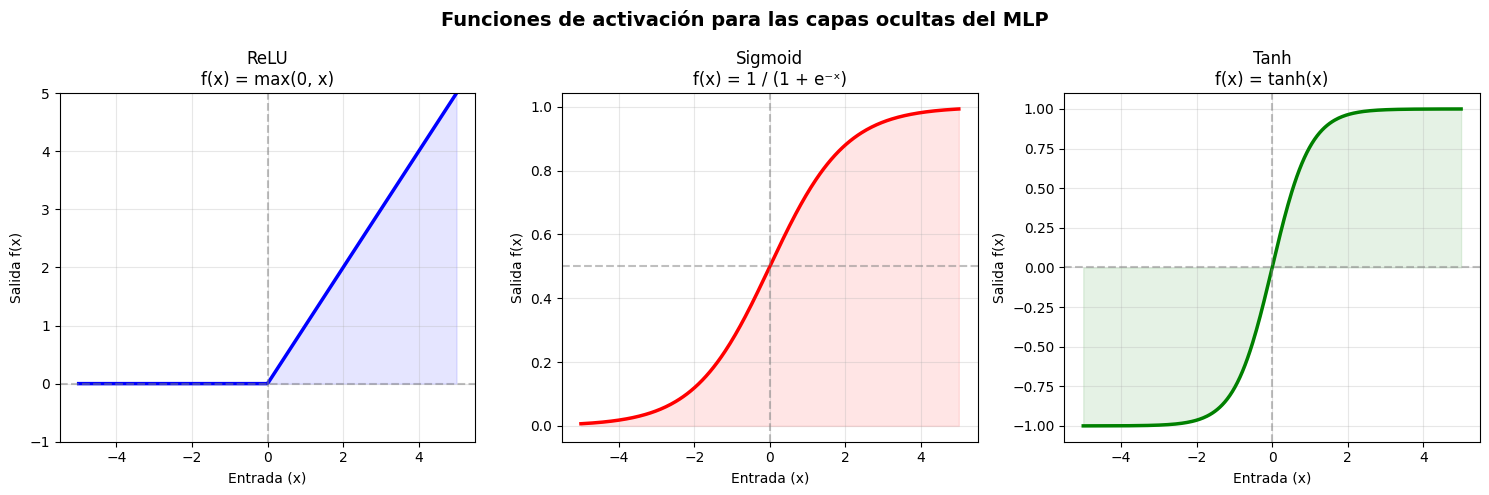

In [ ]:
# Valores de entrada para dibujar las funciones.
import numpy as np
import matplotlib.pyplot as plt
valores_x = np.linspace(-5, 5, 300)

# Calcula las salidas de cada función.
relu = np.maximum(0, valores_x)
sigmoid = 1 / (1 + np.exp(-valores_x))
tanh = np.tanh(valores_x)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    "Funciones de activación para las capas ocultas del MLP",
    fontsize=14,
    fontweight="bold"
)

# ReLU
axes[0].plot(valores_x, relu, color="blue", linewidth=2.5)
axes[0].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
axes[0].axvline(x=0, color="gray", linestyle="--", alpha=0.5)
axes[0].set_title("ReLU\nf(x) = max(0, x)", fontsize=12)
axes[0].set_xlabel("Entrada (x)")
axes[0].set_ylabel("Salida f(x)")
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-1, 5)
axes[0].fill_between(valores_x, relu, alpha=0.1, color="blue")

# Sigmoid
axes[1].plot(valores_x, sigmoid, color="red", linewidth=2.5)
axes[1].axhline(y=0.5, color="gray", linestyle="--", alpha=0.5)
axes[1].axvline(x=0, color="gray", linestyle="--", alpha=0.5)
axes[1].set_title("Sigmoid\nf(x) = 1 / (1 + e⁻ˣ)", fontsize=12)
axes[1].set_xlabel("Entrada (x)")
axes[1].set_ylabel("Salida f(x)")
axes[1].grid(True, alpha=0.3)
axes[1].fill_between(valores_x, sigmoid, alpha=0.1, color="red")

# Tanh
axes[2].plot(valores_x, tanh, color="green", linewidth=2.5)
axes[2].axhline(y=0, color="gray", linestyle="--", alpha=0.5)
axes[2].axvline(x=0, color="gray", linestyle="--", alpha=0.5)
axes[2].set_title("Tanh\nf(x) = tanh(x)", fontsize=12)
axes[2].set_xlabel("Entrada (x)")
axes[2].set_ylabel("Salida f(x)")
axes[2].grid(True, alpha=0.3)
axes[2].fill_between(valores_x, tanh, alpha=0.1, color="green")

plt.tight_layout()
plt.savefig("funciones_activacion_cifar10.png", dpi=150, bbox_inches="tight")
plt.show()

#### Entrenamiento comparativo

In [13]:
from IPython import display
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

funciones_activacion = ["relu", "sigmoid", "tanh"]

historiales_activacion = {}
modelos_activacion = {}
resultados_activacion = {}

for funcion in funciones_activacion:
    print("\n" + "=" * 55)
    print(f"Entrenando el MLP con activación {funcion.upper()}")
    print("=" * 55)

    # Reinicia la semilla para favorecer una comparación reproducible.
    tf.keras.utils.set_random_seed(42)

    # Se mantiene la arquitectura base y solo cambia
    # la activación de las capas ocultas.
    modelo_experimento = models.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(512, activation=funcion),
        layers.Dense(256, activation=funcion),
        layers.Dense(128, activation=funcion),
        layers.Dense(10, activation="softmax")
    ])

    modelo_experimento.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    parada_temprana = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=0
    )

    historial = modelo_experimento.fit(
        x_train,
        y_train,
        epochs=30,
        batch_size=64,
        validation_data=(x_val, y_val),
        callbacks=[parada_temprana],
        verbose=1
    )

    # Busca la época con menor pérdida de validación.
    mejor_indice = int(np.argmin(historial.history["val_loss"]))

    historiales_activacion[funcion] = historial
    modelos_activacion[funcion] = modelo_experimento

    resultados_activacion[funcion] = {
        "Mejor época": mejor_indice + 1,
        "Train accuracy": historial.history["accuracy"][mejor_indice],
        "Val accuracy": historial.history["val_accuracy"][mejor_indice],
        "Train loss": historial.history["loss"][mejor_indice],
        "Val loss": historial.history["val_loss"][mejor_indice],
        "Épocas ejecutadas": len(historial.history["accuracy"])
    }

    print(f"\nMejor época según val_loss: {mejor_indice + 1}")
    print(
        f"Train accuracy: "
        f"{historial.history['accuracy'][mejor_indice] * 100:.2f}%"
    )
    print(
        f"Val accuracy: "
        f"{historial.history['val_accuracy'][mejor_indice] * 100:.2f}%"
    )
    print(f"Train loss: {historial.history['loss'][mejor_indice]:.4f}")
    print(f"Val loss: {historial.history['val_loss'][mejor_indice]:.4f}")
    print(f"Épocas ejecutadas: {len(historial.history['accuracy'])}")

# Muestra la tabla comparativa al terminar los tres entrenamientos.
tabla_activaciones = pd.DataFrame(resultados_activacion).T
display(tabla_activaciones.round(4))


Entrenando el MLP con activación RELU
Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3181 - loss: 1.8818 - val_accuracy: 0.3454 - val_loss: 1.8305
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3905 - loss: 1.6960 - val_accuracy: 0.3836 - val_loss: 1.7494
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4252 - loss: 1.6035 - val_accuracy: 0.4086 - val_loss: 1.6582
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4486 - loss: 1.5404 - val_accuracy: 0.4206 - val_loss: 1.6232
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4646 - loss: 1.4958 - val_accuracy: 0.4270 - val_loss: 1.6126
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4791 - loss: 1.4596 - val_accuracy: 0.4488 - val_loss: 1.5605
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4913 - loss: 1.4224 - val_accuracy: 0.4576 - val_loss: 1.5371
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0

TypeError: 'module' object is not callable

In [14]:
tabla_activaciones = pd.DataFrame(resultados_activacion).T
print(tabla_activaciones.round(4).to_string())

         Mejor época  Train accuracy  Val accuracy  Train loss  Val loss  Épocas ejecutadas
relu            10.0          0.5211        0.4662      1.3361    1.5172               15.0
sigmoid         27.0          0.5282        0.4572      1.3191    1.5319               30.0
tanh             8.0          0.3458        0.3454      1.8121    1.8142               13.0


En la comparación de funciones de activación, ReLU obtuvo el mejor resultado de validación, con un accuracy de 46,62 % y una pérdida de 1,5172. Sigmoid tuvo un resultado cercano, con 45,72 % y una pérdida de 1,5319. Tanh alcanzó un accuracy menor, de 34,54 %, y una pérdida de 1,8142. En esta ejecución, ReLU fue la opción más adecuada para las capas ocultas de esta arquitectura. La comparación usa el conjunto de validación; el conjunto de prueba sigue reservado para la evaluación final.

#### Gráficos comparativos

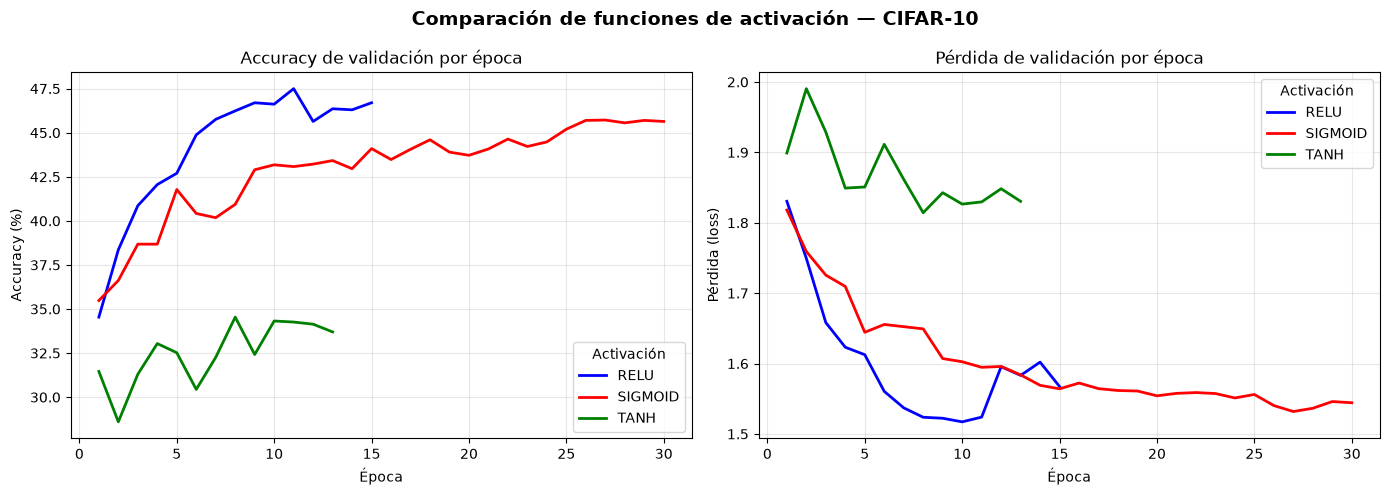

In [15]:
colores_activacion = {
    "relu": "blue",
    "sigmoid": "red",
    "tanh": "green"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Comparación de funciones de activación — CIFAR-10",
    fontsize=14,
    fontweight="bold"
)

for funcion in funciones_activacion:
    historial = historiales_activacion[funcion]
    epocas = range(1, len(historial.history["val_accuracy"]) + 1)

    # Accuracy de validación.
    axes[0].plot(
        epocas,
        [valor * 100 for valor in historial.history["val_accuracy"]],
        color=colores_activacion[funcion],
        linewidth=2,
        label=funcion.upper()
    )

    # Pérdida de validación.
    axes[1].plot(
        epocas,
        historial.history["val_loss"],
        color=colores_activacion[funcion],
        linewidth=2,
        label=funcion.upper()
    )

axes[0].set_title("Accuracy de validación por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend(title="Activación")
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Pérdida de validación por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Pérdida (loss)")
axes[1].legend(title="Activación")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "comparacion_funciones_activacion.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

En las curvas de validación, ReLU alcanzó el mayor accuracy y la menor pérdida entre las funciones comparadas. Sigmoid también mejoró durante el entrenamiento, aunque quedó ligeramente por debajo de ReLU. Tanh obtuvo menor accuracy y mantuvo una pérdida más alta. Por lo tanto, en este experimento ReLU fue la activación más adecuada para las capas ocultas del MLP.

#### Tabla comparativa

In [16]:
filas_activacion = []

for funcion in funciones_activacion:
    resultado = resultados_activacion[funcion]

    filas_activacion.append({
        "Función": funcion.upper(),
        "Mejor época": resultado["Mejor época"],
        "Train Accuracy": f'{resultado["Train accuracy"] * 100:.2f}%',
        "Val Accuracy": f'{resultado["Val accuracy"] * 100:.2f}%',
        "Train Loss": f'{resultado["Train loss"]:.4f}',
        "Val Loss": f'{resultado["Val loss"]:.4f}',
        "Épocas ejecutadas": resultado["Épocas ejecutadas"]
    })

df_resultados_activacion = pd.DataFrame(filas_activacion)

print("\n" + "=" * 85)
print("       COMPARACIÓN DE FUNCIONES DE ACTIVACIÓN — VALIDACIÓN")
print("=" * 85)
print(df_resultados_activacion.to_string(index=False))
print("=" * 85)

# Selecciona la función con menor pérdida de validación.
mejor_funcion = min(
    resultados_activacion,
    key=lambda funcion: resultados_activacion[funcion]["Val loss"]
)

print(f"\nMejor activación según val_loss: {mejor_funcion.upper()}")
print(
    f"Val Accuracy: "
    f"{resultados_activacion[mejor_funcion]['Val accuracy'] * 100:.2f}%"
)
print(
    f"Val Loss: "
    f"{resultados_activacion[mejor_funcion]['Val loss']:.4f}"
)


       COMPARACIÓN DE FUNCIONES DE ACTIVACIÓN — VALIDACIÓN
Función  Mejor época Train Accuracy Val Accuracy Train Loss Val Loss  Épocas ejecutadas
   RELU           10         52.11%       46.62%     1.3361   1.5172                 15
SIGMOID           27         52.82%       45.72%     1.3191   1.5319                 30
   TANH            8         34.58%       34.54%     1.8121   1.8142                 13

Mejor activación según val_loss: RELU
Val Accuracy: 46.62%
Val Loss: 1.5172


En esta comparación, ReLU obtuvo la menor pérdida de validación (1,5172) y el mayor accuracy de validación registrado en la época seleccionada por val_loss (46,62 %). Sigmoid alcanzó un accuracy de entrenamiento algo mayor, pero su rendimiento de validación fue inferior (45,72 %), lo que indica que ese mejor ajuste a entrenamiento no se tradujo en una mejora de generalización. Tanh obtuvo un accuracy de 34,54 % y una pérdida de 1,8142, por lo que fue la opción menos efectiva en esta configuración. Se selecciona ReLU para continuar los experimentos; la evaluación con el conjunto de prueba queda para el final.

### 6.3 Análisis de Resultados — Funciones de Activación

#### Tabla comparativa

| Función | Mejor época según val_loss | Train Accuracy | Val Accuracy | Train Loss | Val Loss | Epocas ejecutadas|
|---|---|---|---|---| ---| ---|
| **ReLU** | 10 | 52,11 %| 46,62 % | 1,3361 | 1,5172 | 15| 
| **Sigmoid** | 27 | 52,82 % | 45,72 % | 1,3191 | 1,5319 | 30| 
| **Tanh** | 8 | 34,58 %| 34,54 % | 31,8121 | 1,8142 | 13| 

En esta comparación, ReLU obtuvo el mejor resultado de validación según la menor pérdida (val_loss = 1,5172), junto con un accuracy de validación de 46,62 %. Sigmoid quedó cerca, con un accuracy de 45,72 % y una pérdida de 1,5319. Tanh obtuvo el resultado más bajo, con 34,54 % de accuracy y pérdida de 1,8142.
ReLU y Tanh se detuvieron antes de las 30 épocas porque EarlyStopping dejó de detectar mejoras en val_loss durante el período de paciencia configurado. Sigmoid alcanzó las 30 épocas máximas. Esto describe lo ocurrido en estas ejecuciones; por sí solo, no demuestra por qué una activación rindió mejor. Con estos resultados, seleccionamos ReLU para los siguientes experimentos. El conjunto de prueba permanece reservado para la evaluación final.

#### Elección final para el modelo
En esta comparación, seleccionamos ReLU para los siguientes experimentos porque obtuvo la menor pérdida de validación (1,5172) y el mayor accuracy de validación (46,62 %). Sigmoid quedó cerca, con 45,72 % de accuracy y una pérdida de 1,5319: la diferencia de accuracy fue de 0,90 puntos porcentuales.
Esta elección se basa en los resultados de validación de esta ejecución. Más adelante podríamos observar cambios al ajustar otros hiperparámetros. El conjunto de prueba se mantiene reservado para evaluar la configuración final.

---
## 7. Optimización con Dropout y Regularización

### 7.1 Técnicas a aplicar
**Dropout**

Durante el entrenamiento, Dropout desactiva aleatoriamente una proporción de neuronas. Esto puede reducir la dependencia del modelo en neuronas específicas y ayudar a limitar el sobreajuste. En evaluación, Dropout se desactiva.

En este proyecto probaremos las tasas de 10 % y 30 %, comparándolas con el modelo base sin Dropout. Ya observamos que su efecto puede variar: una tasa mayor no garantiza un mejor resultado.
Regularización L2

L2 añade una penalización a la pérdida cuando los pesos del modelo tienen valores grandes:

L_total = L_clasificación + λ ∑ (w_i)²


En Keras, aplicaremos L2 a los pesos de las capas densas ocultas. Como valor inicial usaremos . Esta penalización busca limitar los pesos grandes y reducir el sobreajuste.

### 7.2 Métodologia de comparación
Compararemos estas configuraciones:
1. Modelo base: sin Dropout ni L2.
2. Dropout 10 %: sin L2.
3. Dropout 30 %: sin L2.
4. L2 (λ = 0,0001): sin Dropout.
5. Dropout 10 % + L2 (λ = 0,0001): combinación de ambas técnicas. 

En todas las pruebas mantendremos la arquitectura MLP, ReLU en las capas ocultas, softmax en la salida, Adam con tasa de aprendizaje de 0,001, la función Sparse Categorical Crossentropy, el tamaño de batch y los mismos conjuntos de entrenamiento y validación. Usaremos EarlyStopping según la pérdida de validación. Compararemos accuracy y pérdida de validación para elegir una configuración; el conjunto de prueba seguirá reservado para la evaluación final.

#### Entrenamiento comparativo

In [17]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping

configuraciones_reg = {
    "Sin regularización": {"dropout": 0.0, "l2": 0.0},
    "Dropout 10%": {"dropout": 0.1, "l2": 0.0},
    "Dropout 30%": {"dropout": 0.3, "l2": 0.0},
    "Solo L2": {"dropout": 0.0, "l2": 0.0001},
    "Dropout 10% + L2": {"dropout": 0.1, "l2": 0.0001},
}

historiales_reg = {}
modelos_reg = {}
resultados_reg = {}

for nombre, config in configuraciones_reg.items():
    print("\n" + "=" * 55)
    print(f"Configuración: {nombre}")
    print("=" * 55)

    # Reinicia la semilla para favorecer una comparación reproducible.
    tf.keras.utils.set_random_seed(42)

    # Activa L2 solo en las configuraciones que lo solicitan.
    regularizador = (
        regularizers.l2(config["l2"])
        if config["l2"] > 0
        else None
    )

    capas_modelo = [
        layers.Input(shape=(3072,)),

        layers.Dense(
            512,
            activation="relu",
            kernel_regularizer=regularizador
        ),
    ]

    if config["dropout"] > 0:
        capas_modelo.append(layers.Dropout(config["dropout"]))

    capas_modelo.append(
        layers.Dense(
            256,
            activation="relu",
            kernel_regularizer=regularizador
        )
    )

    if config["dropout"] > 0:
        capas_modelo.append(layers.Dropout(config["dropout"]))

    capas_modelo.append(
        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizador
        )
    )

    if config["dropout"] > 0:
        capas_modelo.append(layers.Dropout(config["dropout"]))

    capas_modelo.append(layers.Dense(10, activation="softmax"))

    modelo_reg = models.Sequential(capas_modelo)

    modelo_reg.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    parada_temprana = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=0
    )

    historial = modelo_reg.fit(
        x_train,
        y_train,
        epochs=30,
        batch_size=64,
        validation_data=(x_val, y_val),
        callbacks=[parada_temprana],
        verbose=0
    )

    # Usa las métricas de la época con menor pérdida de validación.
    mejor_indice = int(np.argmin(historial.history["val_loss"]))

    historiales_reg[nombre] = historial
    modelos_reg[nombre] = modelo_reg

    resultados_reg[nombre] = {
        "Mejor época": mejor_indice + 1,
        "Train accuracy": historial.history["accuracy"][mejor_indice],
        "Val accuracy": historial.history["val_accuracy"][mejor_indice],
        "Train loss": historial.history["loss"][mejor_indice],
        "Val loss": historial.history["val_loss"][mejor_indice],
        "Épocas ejecutadas": len(historial.history["accuracy"])
    }

    print(f"Mejor época: {mejor_indice + 1}")
    print(
        f"Val accuracy: "
        f"{historial.history['val_accuracy'][mejor_indice] * 100:.2f}%"
    )
    print(
        f"Val loss: "
        f"{historial.history['val_loss'][mejor_indice]:.4f}"
    )
    print(f"Épocas ejecutadas: {len(historial.history['accuracy'])}")

# Tabla comparativa de validación.
tabla_reg = pd.DataFrame(resultados_reg).T
print("\n" + "=" * 85)
print("COMPARACIÓN DE REGULARIZACIÓN — VALIDACIÓN")
print("=" * 85)
print(tabla_reg.round(4).to_string())


Configuración: Sin regularización
Mejor época: 10
Val accuracy: 46.62%
Val loss: 1.5172
Épocas ejecutadas: 15

Configuración: Dropout 10%
Mejor época: 18
Val accuracy: 46.90%
Val loss: 1.4806
Épocas ejecutadas: 23

Configuración: Dropout 30%
Mejor época: 18
Val accuracy: 39.54%
Val loss: 1.7026
Épocas ejecutadas: 23

Configuración: Solo L2
Mejor época: 7
Val accuracy: 46.40%
Val loss: 1.5629
Épocas ejecutadas: 12

Configuración: Dropout 10% + L2
Mejor época: 18
Val accuracy: 46.60%
Val loss: 1.5492
Épocas ejecutadas: 23

COMPARACIÓN DE REGULARIZACIÓN — VALIDACIÓN
                    Mejor época  Train accuracy  Val accuracy  Train loss  Val loss  Épocas ejecutadas
Sin regularización         10.0          0.5211        0.4662      1.3361    1.5172               15.0
Dropout 10%                18.0          0.4697        0.4690      1.4655    1.4806               23.0
Dropout 30%                18.0          0.3529        0.3954      1.7753    1.7026               23.0
Solo L2          

#### Gráficos comparativos

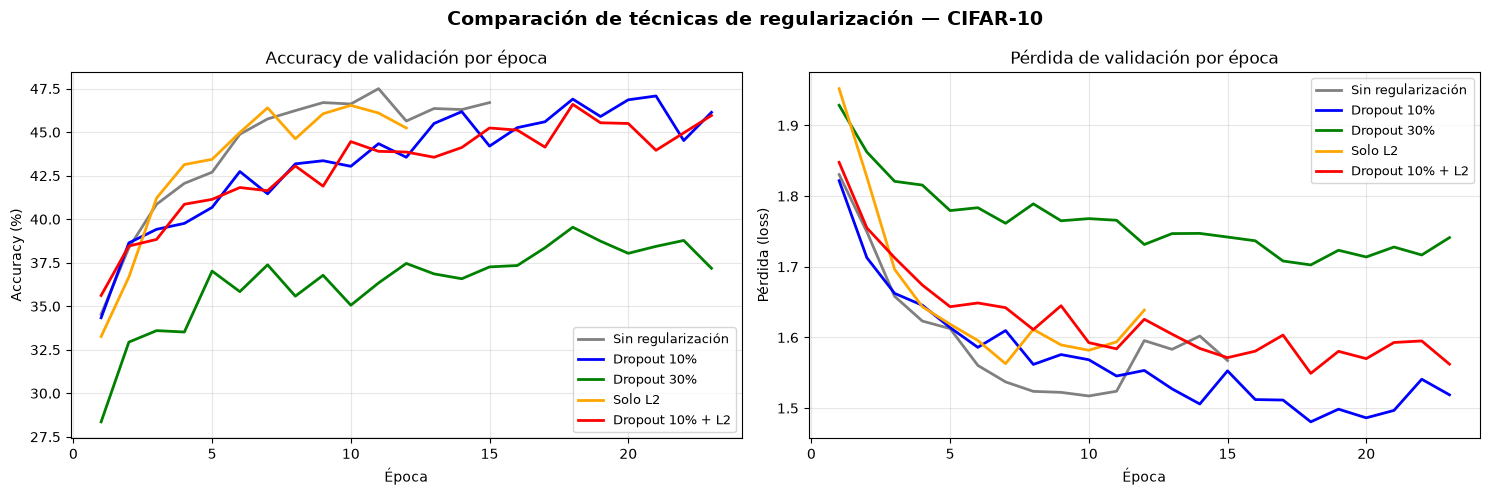

In [18]:
colores_reg = {
    "Sin regularización": "gray",
    "Dropout 10%": "blue",
    "Dropout 30%": "green",
    "Solo L2": "orange",
    "Dropout 10% + L2": "red",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    "Comparación de técnicas de regularización — CIFAR-10",
    fontsize=14,
    fontweight="bold"
)

for nombre in configuraciones_reg:
    historial = historiales_reg[nombre]
    epocas = range(1, len(historial.history["val_accuracy"]) + 1)

    # Accuracy de validación.
    axes[0].plot(
        epocas,
        [valor * 100 for valor in historial.history["val_accuracy"]],
        color=colores_reg[nombre],
        linewidth=2,
        label=nombre
    )

    # Pérdida de validación.
    axes[1].plot(
        epocas,
        historial.history["val_loss"],
        color=colores_reg[nombre],
        linewidth=2,
        label=nombre
    )

axes[0].set_title("Accuracy de validación por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Pérdida de validación por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Pérdida (loss)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "comparacion_regularizacion_cifar10.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

#### Tabla comparativa

In [19]:
filas_reg = []

for nombre in configuraciones_reg:
    resultado = resultados_reg[nombre]

    filas_reg.append({
        "Configuración": nombre,
        "Mejor época": resultado["Mejor época"],
        "Train Accuracy": f'{resultado["Train accuracy"] * 100:.2f}%',
        "Val Accuracy": f'{resultado["Val accuracy"] * 100:.2f}%',
        "Train Loss": f'{resultado["Train loss"]:.4f}',
        "Val Loss": f'{resultado["Val loss"]:.4f}',
        "Épocas ejecutadas": resultado["Épocas ejecutadas"]
    })

df_reg = pd.DataFrame(filas_reg)

print("\n" + "=" * 100)
print("COMPARACIÓN DE TÉCNICAS DE REGULARIZACIÓN — VALIDACIÓN")
print("=" * 100)
print(df_reg.to_string(index=False))
print("=" * 100)

# Identifica la configuración con mayor Val Accuracy
# en la época seleccionada por menor val_loss.
mejor_reg = max(
    resultados_reg,
    key=lambda nombre: resultados_reg[nombre]["Val accuracy"]
)

print(f"\nMayor Val Accuracy: {mejor_reg}")
print(
    f"Val Accuracy: "
    f"{resultados_reg[mejor_reg]['Val accuracy'] * 100:.2f}%"
)
print(
    f"Val Loss: "
    f"{resultados_reg[mejor_reg]['Val loss']:.4f}"
)


COMPARACIÓN DE TÉCNICAS DE REGULARIZACIÓN — VALIDACIÓN
     Configuración  Mejor época Train Accuracy Val Accuracy Train Loss Val Loss  Épocas ejecutadas
Sin regularización           10         52.11%       46.62%     1.3361   1.5172                 15
       Dropout 10%           18         46.97%       46.90%     1.4655   1.4806                 23
       Dropout 30%           18         35.29%       39.54%     1.7753   1.7026                 23
           Solo L2            7         48.17%       46.40%     1.4975   1.5629                 12
  Dropout 10% + L2           18         45.77%       46.60%     1.5613   1.5492                 23

Mayor Val Accuracy: Dropout 10%
Val Accuracy: 46.90%
Val Loss: 1.4806


### 7.3 Batch Normalization
Batch Normalization normaliza las activaciones que recibe en una capa. Durante el entrenamiento usa la media y la varianza del batch; durante la inferencia utiliza promedios acumulados durante el entrenamiento. También aprende parámetros que permiten ajustar la escala y el desplazamiento de esos valores.

x̂ = (x - μ) / √(σ² + ε)

En nuestro MLP se puede probar entre la capa densa y la activación:

Dense → Batch Normalization → 

Batch Normalization puede ayudar a estabilizar el entrenamiento, pero su efecto se debe comprobar con los resultados de validación. La evaluaremos como una configuración adicional, manteniendo iguales la arquitectura restante, los datos y los demás hiperparámetros.

### 7.4 Ajuste de la tasa de aprendizaje con ReduceLROnPlateau
ReduceLROnPlateau reduce la tasa de aprendizaje cuando la métrica monitoreada deja de mejorar. En nuestro experimento monitoreará val_loss. Documentación de Keras: ReduceLROnPlateau

- Tasa inicial: 0,001, igual a la configuración base.
- Factor: 0,5; cuando corresponda, la tasa se multiplica por 0,5.
- Paciencia: 3 épocas sin mejora de val_loss.
- Tasa mínima: 0,00001.

La idea es comenzar con pasos de aprendizaje mayores y reducirlos si la validación se estanca. Para darle al modelo tiempo de responder a esa reducción, al probar este callback conviene aumentar la paciencia de EarlyStopping (por ejemplo, a 8 épocas) y ejecutar primero ReduceLROnPlateau. Compararemos el resultado con el entrenamiento de tasa fija, usando el mismo conjunto de validación.


#### Modelo con Batch Norm + LR Scheduler

In [20]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def modelo_con_batchnorm(usar_batchnorm=False):
    """Construye el MLP base con ReLU y, opcionalmente, Batch Normalization."""

    capas_modelo = [layers.Input(shape=(3072,))]

    for unidades in [512, 256, 128]:
        if usar_batchnorm:
            capas_modelo.append(
                layers.Dense(unidades, use_bias=False)
            )
            capas_modelo.append(layers.BatchNormalization())
            capas_modelo.append(layers.Activation("relu"))
        else:
            capas_modelo.append(
                layers.Dense(unidades, activation="relu")
            )

    capas_modelo.append(layers.Dense(10, activation="softmax"))

    modelo = models.Sequential(capas_modelo)

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return modelo


# Se mantiene fija la tasa de Dropout en 0 % para aislar
# los efectos de Batch Normalization y del scheduler.
configs_avanzadas = {
    "Base ReLU (sin BN, tasa fija)": {
        "batchnorm": False,
        "lr_scheduler": False
    },
    "Batch Normalization": {
        "batchnorm": True,
        "lr_scheduler": False
    },
    "ReduceLROnPlateau": {
        "batchnorm": False,
        "lr_scheduler": True
    },
    "Batch Normalization + ReduceLROnPlateau": {
        "batchnorm": True,
        "lr_scheduler": True
    }
}

historiales_avz = {}
modelos_avz = {}
resultados_avz = {}

for nombre, config in configs_avanzadas.items():
    print("\n" + "=" * 60)
    print(f"Configuración: {nombre}")
    print("=" * 60)

    tf.keras.utils.set_random_seed(42)

    modelo_avz = modelo_con_batchnorm(
        usar_batchnorm=config["batchnorm"]
    )

    callbacks_avz = []

    # Primero se permite reducir la tasa de aprendizaje.
    if config["lr_scheduler"]:
        callbacks_avz.append(
            ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=3,
                min_lr=0.00001,
                verbose=1
            )
        )

    # EarlyStopping tiene más paciencia para permitir que el scheduler actúe.
    callbacks_avz.append(
        EarlyStopping(
            monitor="val_loss",
            patience=8,
            restore_best_weights=True,
            verbose=0
        )
    )

    historial_avz = modelo_avz.fit(
        x_train,
        y_train,
        epochs=30,
        batch_size=64,
        validation_data=(x_val, y_val),
        callbacks=callbacks_avz,
        verbose=0
    )

    mejor_indice = int(
        np.argmin(historial_avz.history["val_loss"])
    )

    historiales_avz[nombre] = historial_avz
    modelos_avz[nombre] = modelo_avz

    resultados_avz[nombre] = {
        "Mejor época": mejor_indice + 1,
        "Train accuracy": historial_avz.history["accuracy"][mejor_indice],
        "Val accuracy": historial_avz.history["val_accuracy"][mejor_indice],
        "Train loss": historial_avz.history["loss"][mejor_indice],
        "Val loss": historial_avz.history["val_loss"][mejor_indice],
        "Épocas ejecutadas": len(historial_avz.history["accuracy"])
    }

    print(f"Mejor época según val_loss: {mejor_indice + 1}")
    print(
        f"Val accuracy: "
        f"{historial_avz.history['val_accuracy'][mejor_indice] * 100:.2f}%"
    )
    print(
        f"Val loss: "
        f"{historial_avz.history['val_loss'][mejor_indice]:.4f}"
    )
    print(
        f"Épocas ejecutadas: "
        f"{len(historial_avz.history['accuracy'])}"
    )


# Tabla con las métricas de validación.
tabla_avz = pd.DataFrame(resultados_avz).T

print("\n" + "=" * 95)
print("COMPARACIÓN DE BATCH NORMALIZATION Y SCHEDULER — VALIDACIÓN")
print("=" * 95)
print(tabla_avz.round(4).to_string())


Configuración: Base ReLU (sin BN, tasa fija)
Mejor época según val_loss: 10
Val accuracy: 46.62%
Val loss: 1.5172
Épocas ejecutadas: 18

Configuración: Batch Normalization
Mejor época según val_loss: 4
Val accuracy: 43.88%
Val loss: 1.5992
Épocas ejecutadas: 12

Configuración: ReduceLROnPlateau

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 24: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 28: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Mejor época según val_loss: 25
Val accuracy: 50.46%
Val loss: 1.4816
Épocas ejecutadas: 30

Configuración: Batch Normalization + ReduceLROnPlateau

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Mejor época 

#### Gráficos comparativos

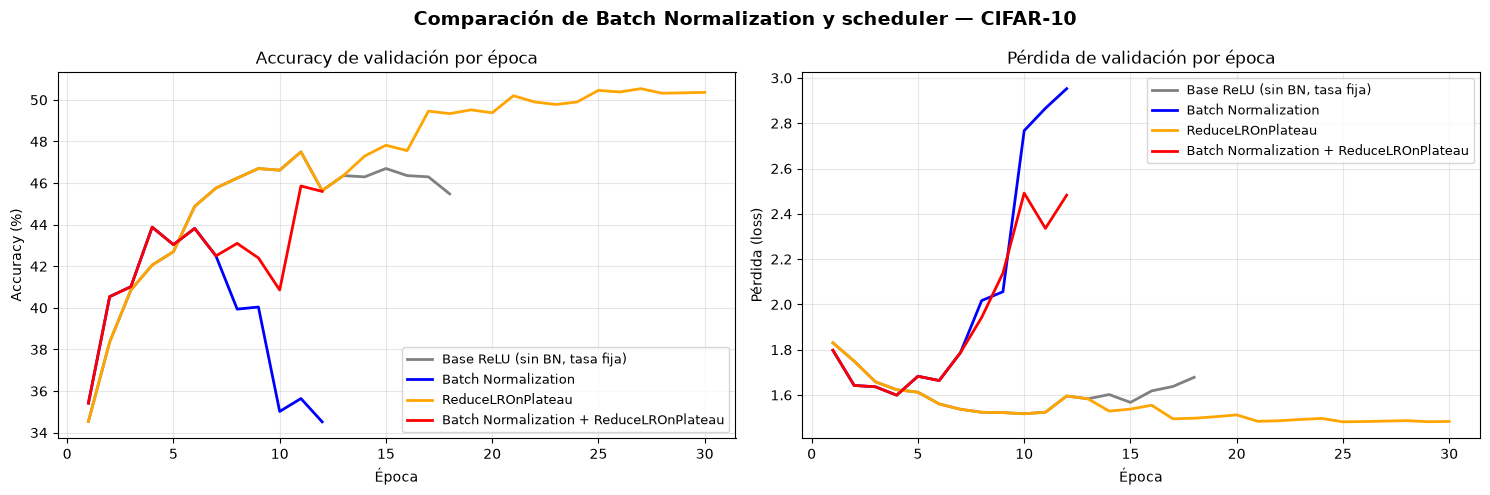

In [21]:
colores_avz = {
    "Base ReLU (sin BN, tasa fija)": "gray",
    "Batch Normalization": "blue",
    "ReduceLROnPlateau": "orange",
    "Batch Normalization + ReduceLROnPlateau": "red"
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    "Comparación de Batch Normalization y scheduler — CIFAR-10",
    fontsize=14,
    fontweight="bold"
)

for nombre in configs_avanzadas:
    historial = historiales_avz[nombre]
    epocas = range(1, len(historial.history["val_accuracy"]) + 1)

    # Accuracy de validación.
    axes[0].plot(
        epocas,
        [valor * 100 for valor in historial.history["val_accuracy"]],
        color=colores_avz[nombre],
        linewidth=2,
        label=nombre
    )

    # Pérdida de validación.
    axes[1].plot(
        epocas,
        historial.history["val_loss"],
        color=colores_avz[nombre],
        linewidth=2,
        label=nombre
    )

axes[0].set_title("Accuracy de validación por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Pérdida de validación por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Pérdida (loss)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "comparacion_batchnorm_scheduler_cifar10.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

#### Tabla comparativa

In [22]:
filas_avz = []

for nombre in configs_avanzadas:
    resultado = resultados_avz[nombre]

    filas_avz.append({
        "Configuración": nombre,
        "Mejor época": resultado["Mejor época"],
        "Train Accuracy": f'{resultado["Train accuracy"] * 100:.2f}%',
        "Val Accuracy": f'{resultado["Val accuracy"] * 100:.2f}%',
        "Train Loss": f'{resultado["Train loss"]:.4f}',
        "Val Loss": f'{resultado["Val loss"]:.4f}',
        "Épocas ejecutadas": resultado["Épocas ejecutadas"]
    })

df_avz = pd.DataFrame(filas_avz)

print("\n" + "=" * 105)
print("COMPARACIÓN DE BATCH NORMALIZATION Y SCHEDULER — VALIDACIÓN")
print("=" * 105)
print(df_avz.to_string(index=False))
print("=" * 105)

# Selecciona la configuración con menor pérdida de validación.
mejor_avz = min(
    resultados_avz,
    key=lambda nombre: resultados_avz[nombre]["Val loss"]
)

print(f"\nMejor configuración según val_loss: {mejor_avz}")
print(
    f"Val Accuracy: "
    f"{resultados_avz[mejor_avz]['Val accuracy'] * 100:.2f}%"
)
print(
    f"Val Loss: "
    f"{resultados_avz[mejor_avz]['Val loss']:.4f}"
)

# Compara con el modelo base de este experimento.
nombre_base_avz = "Base ReLU (sin BN, tasa fija)"
resultado_base_avz = resultados_avz[nombre_base_avz]
resultado_mejor_avz = resultados_avz[mejor_avz]

diferencia_accuracy = (
    resultado_mejor_avz["Val accuracy"]
    - resultado_base_avz["Val accuracy"]
) * 100

diferencia_loss = (
    resultado_base_avz["Val loss"]
    - resultado_mejor_avz["Val loss"]
)

print("\nComparación con el modelo base de este experimento:")
print(
    f"Accuracy de validación base: "
    f"{resultado_base_avz['Val accuracy'] * 100:.2f}%"
)
print(
    f"Accuracy de validación mejor configuración: "
    f"{resultado_mejor_avz['Val accuracy'] * 100:.2f}%"
)
print(
    f"Diferencia de accuracy: "
    f"{diferencia_accuracy:+.2f} puntos porcentuales"
)
print(
    f"Reducción de val_loss: "
    f"{diferencia_loss:+.4f}"
)


COMPARACIÓN DE BATCH NORMALIZATION Y SCHEDULER — VALIDACIÓN
                          Configuración  Mejor época Train Accuracy Val Accuracy Train Loss Val Loss  Épocas ejecutadas
          Base ReLU (sin BN, tasa fija)           10         52.11%       46.62%     1.3361   1.5172                 18
                    Batch Normalization            4         58.82%       43.88%     1.1614   1.5992                 12
                      ReduceLROnPlateau           25         64.37%       50.46%     0.9968   1.4816                 30
Batch Normalization + ReduceLROnPlateau            4         58.82%       43.88%     1.1614   1.5992                 12

Mejor configuración según val_loss: ReduceLROnPlateau
Val Accuracy: 50.46%
Val Loss: 1.4816

Comparación con el modelo base de este experimento:
Accuracy de validación base: 46.62%
Accuracy de validación mejor configuración: 50.46%
Diferencia de accuracy: +3.84 puntos porcentuales
Reducción de val_loss: +0.0357


### 7.5 Análisis de Resultados — Optimización


In [23]:
def tabla_resumen_validacion(resultados):
    filas = []

    for nombre, resultado in resultados.items():
        filas.append({
            "Configuración": nombre,
            "Mejor época": resultado["Mejor época"],
            "Train Accuracy": f'{resultado["Train accuracy"] * 100:.2f}%',
            "Val Accuracy": f'{resultado["Val accuracy"] * 100:.2f}%',
            "Train Loss": f'{resultado["Train loss"]:.4f}',
            "Val Loss": f'{resultado["Val loss"]:.4f}',
            "Épocas ejecutadas": resultado["Épocas ejecutadas"]
        })

    return pd.DataFrame(filas)

print("TÉCNICAS DE REGULARIZACIÓN")
print(tabla_resumen_validacion(resultados_reg).to_string(index=False))

print("\nBATCH NORMALIZATION Y SCHEDULER")
print(tabla_resumen_validacion(resultados_avz).to_string(index=False))

TÉCNICAS DE REGULARIZACIÓN
     Configuración  Mejor época Train Accuracy Val Accuracy Train Loss Val Loss  Épocas ejecutadas
Sin regularización           10         52.11%       46.62%     1.3361   1.5172                 15
       Dropout 10%           18         46.97%       46.90%     1.4655   1.4806                 23
       Dropout 30%           18         35.29%       39.54%     1.7753   1.7026                 23
           Solo L2            7         48.17%       46.40%     1.4975   1.5629                 12
  Dropout 10% + L2           18         45.77%       46.60%     1.5613   1.5492                 23

BATCH NORMALIZATION Y SCHEDULER
                          Configuración  Mejor época Train Accuracy Val Accuracy Train Loss Val Loss  Épocas ejecutadas
          Base ReLU (sin BN, tasa fija)           10         52.11%       46.62%     1.3361   1.5172                 18
                    Batch Normalization            4         58.82%       43.88%     1.1614   1.5992      

### 7.5 Análisis de Resultados — Optimización
| Configuración | Mejor época | Train Accuracy | Val Accuracy | Train Loss | Val Loss |
|---|---:|---:|---:|---:|---:|
| Sin regularización | 10 | 52,11 % | 46,62 % | 1,3361 | 1,5172 |
| Dropout 10 % | 18 | 46,97 % | **46,90 %** | 1,4655 | **1,4806** |
| Dropout 30 % | 18 | 35,29 % | 39,54 % | 1,7753 | 1,7026 |
| Solo L2 | 7 | 48,17 % | 46,40 % | 1,4975 | 1,5629 |
| Dropout 10 % + L2 | 18 | 45,77 % | 46,60 % | 1,5613 | 1,5492 |

### Tabla resumen — Batch Normalization y scheduler

| Configuración | Mejor época | Train Accuracy | Val Accuracy | Train Loss | Val Loss |
|---|---:|---:|---:|---:|---:|
| Base ReLU, sin BN y tasa fija | 10 | 52,11 % | 46,62 % | 1,3361 | 1,5172 |
| Batch Normalization | 4 | 58,82 % | 43,88 % | 1,1614 | 1,5992 |
| **ReduceLROnPlateau** | **25** | **64,37 %** | **50,46 %** | **0,9968** | **1,4816** |
| Batch Normalization + ReduceLROnPlateau | 4 | 58,82 % | 43,88 % | 1,1614 | 1,5992 |

### Hallazgos
En las pruebas de regularización, Dropout al 10 % obtuvo la menor pérdida de validación (1,4806) y un accuracy de 46,90 %, ligeramente superior al modelo sin regularización. Dropout al 30 % tuvo menor accuracy y mayor pérdida, por lo que esa tasa fue demasiado alta para esta configuración. L2 sola y su combinación con Dropout al 10 % tampoco superaron el resultado de Dropout al 10 % por sí solo.

En la comparación de optimización, ReduceLROnPlateau sin Batch Normalization obtuvo el mayor accuracy de validación: 50,46 %, frente al 46,62 % de la configuración base. Su pérdida de validación fue 1,4816, muy cercana a la de Dropout al 10 % (1,4806). Batch Normalization, sola o combinada con el scheduler, tuvo menor accuracy y mayor pérdida que la base en esta ejecución; combinar ambas técnicas no mejoró los resultados de Batch Normalization sola.

Para continuar, seleccionamos provisionalmente ReLU con ReduceLROnPlateau y sin Batch Normalization, priorizando el accuracy de validación. Dropout al 10 % queda muy cerca en pérdida de validación. La elección se confirmará con las métricas finales y la evaluación del conjunto de prueba.


---
## 8. Experimentos Controlados de Hiperparámetros

### 8.1 Hiperparámetros a experimentar
| Hiperparámetro | Valores a probar | Valor de referencia |
|---|---|---|
| Tasa de aprendizaje | 0,01; 0,001; 0,0001 | 0,001 |
| Tamaño del batch | 32; 64; 128 | 64 |
| Neuronas en las capas ocultas | 256-128-64; 512-256-128; 1024-512-256 | 512-256-128 |
| Optimizador | Adam; SGD; RMSprop | Adam |

### 8.2 Configuración de referencia para los experimentos

Usaremos como referencia la configuración base del MLP:
- Activación oculta: ReLU.
- Arquitectura: 512-256-128 neuronas.
- Activación de salida: softmax, con 10 neuronas.
- Optimizador: Adam.
- Tasa de aprendizaje inicial: 0,001.
- Tamaño del batch: 64.
- Regularización: sin Dropout ni Batch Normalization en la referencia.
- Entrenamiento: hasta 30 épocas, con EarlyStopping y los mismos conjuntos de entrenamiento y validación.


#### Función base para experimentos


In [24]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

def construir_modelo_experimento(
    neuronas=(512, 256, 128),
    learning_rate=0.001,
    optimizador="adam"
):
    """
    Construye el MLP base para experimentos controlados.
    La arquitectura, la activación y la regularización se mantienen fijas.
    """

    if optimizador.lower() == "adam":
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizador.lower() == "sgd":
        opt = tf.keras.optimizers.SGD(
            learning_rate=learning_rate,
            momentum=0.9
        )
    elif optimizador.lower() == "rmsprop":
        opt = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        raise ValueError(
            "Optimizador no reconocido. Usa 'adam', 'sgd' o 'rmsprop'."
        )

    capas_modelo = [layers.Input(shape=(3072,))]

    for numero_neuronas in neuronas:
        capas_modelo.append(
            layers.Dense(numero_neuronas, activation="relu")
        )

    capas_modelo.append(layers.Dense(10, activation="softmax"))

    modelo = models.Sequential(capas_modelo)

    modelo.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return modelo


def entrenar_experimento(
    modelo,
    nombre,
    batch_size=64,
    epochs=30
):
    """Entrena el modelo y devuelve las métricas de su mejor época de validación."""

    parada_temprana = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=0
    )

    historial = modelo.fit(
        x_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_val, y_val),
        callbacks=[parada_temprana],
        verbose=0
    )

    mejor_indice = int(
        np.argmin(historial.history["val_loss"])
    )

    resultado = {
        "Mejor época": mejor_indice + 1,
        "Train accuracy": historial.history["accuracy"][mejor_indice],
        "Val accuracy": historial.history["val_accuracy"][mejor_indice],
        "Train loss": historial.history["loss"][mejor_indice],
        "Val loss": historial.history["val_loss"][mejor_indice],
        "Épocas ejecutadas": len(historial.history["accuracy"])
    }

    print(
        f"{nombre}: "
        f"Val Accuracy={resultado['Val accuracy'] * 100:.2f}% | "
        f"Val Loss={resultado['Val loss']:.4f} | "
        f"Mejor época={resultado['Mejor época']} | "
        f"Épocas ejecutadas={resultado['Épocas ejecutadas']}"
    )

    return historial, resultado

#### Experimento 1: Learning Rate

EXPERIMENTO 1 — TASA DE APRENDIZAJE
LR=0.01: Val Accuracy=35.94% | Val Loss=1.7777 | Mejor época=4 | Épocas ejecutadas=9
LR=0.001: Val Accuracy=46.62% | Val Loss=1.5172 | Mejor época=10 | Épocas ejecutadas=15
LR=0.0001: Val Accuracy=50.36% | Val Loss=1.4301 | Mejor época=18 | Épocas ejecutadas=23


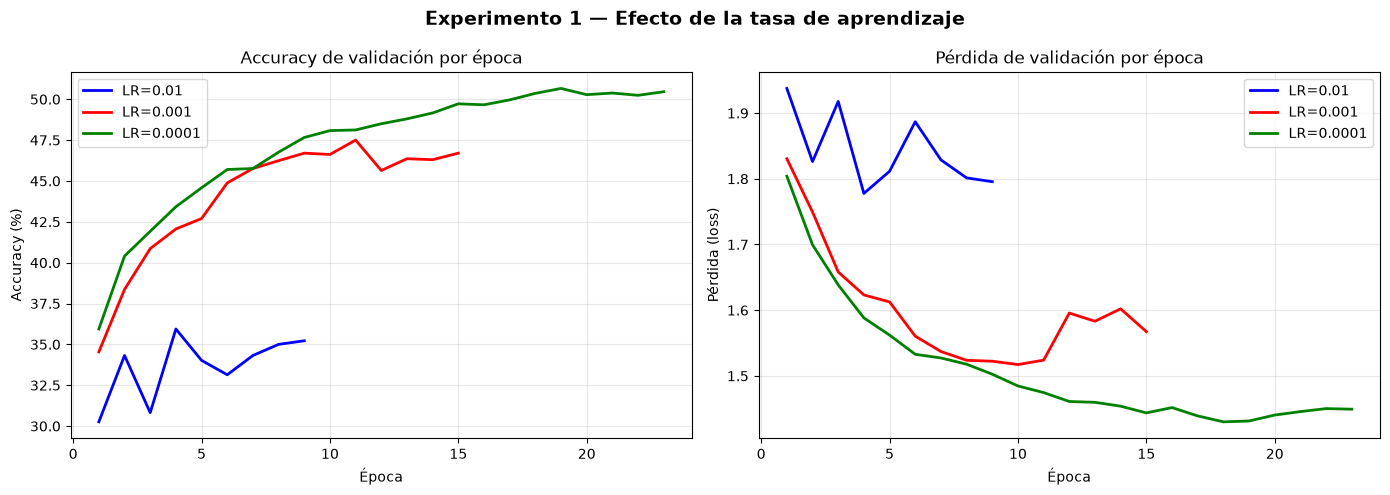


COMPARACIÓN DE TASAS DE APRENDIZAJE — VALIDACIÓN
Learning rate  Mejor época Val Accuracy Val Loss  Épocas ejecutadas
         0.01            4       35.94%   1.7777                  9
        0.001           10       46.62%   1.5172                 15
       0.0001           18       50.36%   1.4301                 23


In [25]:
print("EXPERIMENTO 1 — TASA DE APRENDIZAJE")
print("=" * 55)

learning_rates = [0.01, 0.001, 0.0001]

hist_lr = {}
res_lr = {}

for lr in learning_rates:
    nombre = f"LR={lr}"

    # Usa la misma semilla inicial para cada comparación.
    tf.keras.utils.set_random_seed(42)

    modelo_lr = construir_modelo_experimento(
        learning_rate=lr,
        optimizador="adam"
    )

    historial_lr, resultado_lr = entrenar_experimento(
        modelo_lr,
        nombre=nombre,
        batch_size=64,
        epochs=30
    )

    hist_lr[nombre] = historial_lr
    res_lr[nombre] = resultado_lr


# Gráficos de validación.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Experimento 1 — Efecto de la tasa de aprendizaje",
    fontsize=14,
    fontweight="bold"
)

colores_lr = {
    "LR=0.01": "blue",
    "LR=0.001": "red",
    "LR=0.0001": "green"
}

for nombre, historial in hist_lr.items():
    epocas = range(1, len(historial.history["val_accuracy"]) + 1)

    axes[0].plot(
        epocas,
        [valor * 100 for valor in historial.history["val_accuracy"]],
        color=colores_lr[nombre],
        linewidth=2,
        label=nombre
    )

    axes[1].plot(
        epocas,
        historial.history["val_loss"],
        color=colores_lr[nombre],
        linewidth=2,
        label=nombre
    )

axes[0].set_title("Accuracy de validación por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Pérdida de validación por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Pérdida (loss)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "experimento_1_tasa_aprendizaje.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


# Tabla: métricas de la época con menor pérdida de validación.
filas_lr = []

for nombre, resultado in res_lr.items():
    filas_lr.append({
        "Learning rate": nombre.replace("LR=", ""),
        "Mejor época": resultado["Mejor época"],
        "Val Accuracy": f'{resultado["Val accuracy"] * 100:.2f}%',
        "Val Loss": f'{resultado["Val loss"]:.4f}',
        "Épocas ejecutadas": resultado["Épocas ejecutadas"]
    })

df_lr = pd.DataFrame(filas_lr)

print("\n" + "=" * 75)
print("COMPARACIÓN DE TASAS DE APRENDIZAJE — VALIDACIÓN")
print("=" * 75)
print(df_lr.to_string(index=False))

#### Experimento 2: Batch Size


EXPERIMENTO 2 — TAMAÑO DEL BATCH
Batch=32: Val Accuracy=45.16% | Val Loss=1.5637 | Mejor época=10 | Épocas ejecutadas=15
Batch=64: Val Accuracy=46.62% | Val Loss=1.5172 | Mejor época=10 | Épocas ejecutadas=15
Batch=128: Val Accuracy=47.42% | Val Loss=1.4825 | Mejor época=11 | Épocas ejecutadas=16


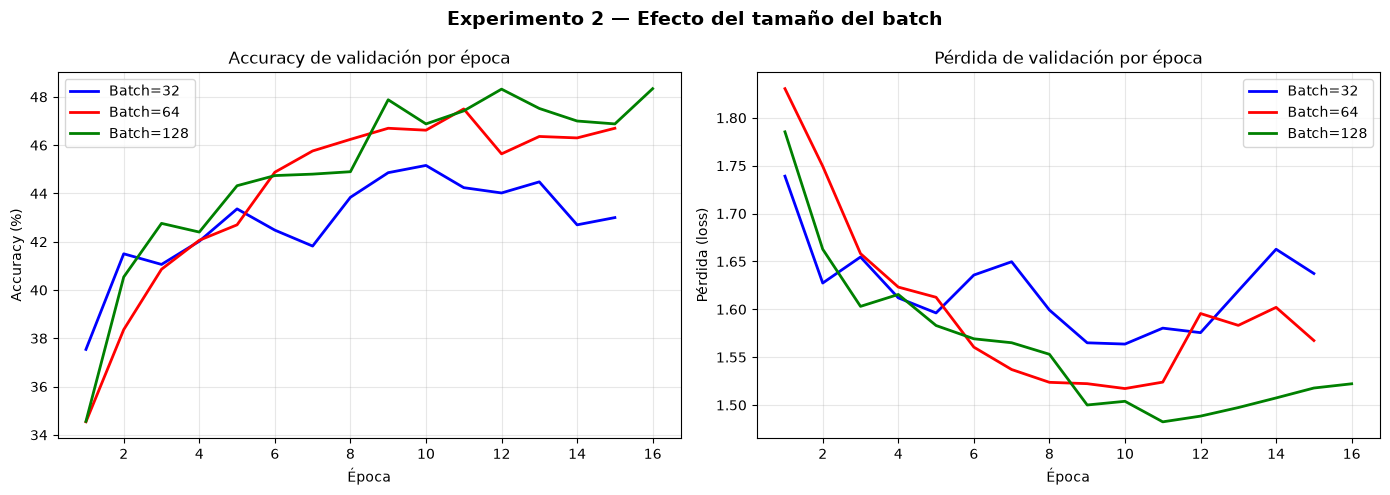


COMPARACIÓN DE TAMAÑOS DE BATCH — VALIDACIÓN
Batch size  Mejor época Val Accuracy Val Loss  Épocas ejecutadas
        32           10       45.16%   1.5637                 15
        64           10       46.62%   1.5172                 15
       128           11       47.42%   1.4825                 16


In [26]:
print("\nEXPERIMENTO 2 — TAMAÑO DEL BATCH")
print("=" * 55)

batch_sizes = [32, 64, 128]

hist_bs = {}
res_bs = {}

for bs in batch_sizes:
    nombre = f"Batch={bs}"

    # Usa la misma semilla inicial en cada comparación.
    tf.keras.utils.set_random_seed(42)

    modelo_bs = construir_modelo_experimento(
        neuronas=(512, 256, 128),
        learning_rate=0.001,
        optimizador="adam"
    )

    historial_bs, resultado_bs = entrenar_experimento(
        modelo_bs,
        nombre=nombre,
        batch_size=bs,
        epochs=30
    )

    hist_bs[nombre] = historial_bs
    res_bs[nombre] = resultado_bs


# Gráficos de validación.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Experimento 2 — Efecto del tamaño del batch",
    fontsize=14,
    fontweight="bold"
)

colores_bs = {
    "Batch=32": "blue",
    "Batch=64": "red",
    "Batch=128": "green"
}

for nombre, historial in hist_bs.items():
    epocas = range(1, len(historial.history["val_accuracy"]) + 1)

    axes[0].plot(
        epocas,
        [valor * 100 for valor in historial.history["val_accuracy"]],
        color=colores_bs[nombre],
        linewidth=2,
        label=nombre
    )

    axes[1].plot(
        epocas,
        historial.history["val_loss"],
        color=colores_bs[nombre],
        linewidth=2,
        label=nombre
    )

axes[0].set_title("Accuracy de validación por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Pérdida de validación por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Pérdida (loss)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "experimento_2_tamano_batch.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


# Tabla con las métricas de la época con menor val_loss.
filas_bs = []

for nombre, resultado in res_bs.items():
    filas_bs.append({
        "Batch size": nombre.replace("Batch=", ""),
        "Mejor época": resultado["Mejor época"],
        "Val Accuracy": f'{resultado["Val accuracy"] * 100:.2f}%',
        "Val Loss": f'{resultado["Val loss"]:.4f}',
        "Épocas ejecutadas": resultado["Épocas ejecutadas"]
    })

df_bs = pd.DataFrame(filas_bs)

print("\n" + "=" * 75)
print("COMPARACIÓN DE TAMAÑOS DE BATCH — VALIDACIÓN")
print("=" * 75)
print(df_bs.to_string(index=False))

#### Experimento 3: Neuronas y Optimizador

In [27]:
print("\nEXPERIMENTO 3 — ARQUITECTURA Y NÚMERO DE NEURONAS")
print("=" * 60)

arquitecturas = {
    "Pequeña (256-128-64)": (256, 128, 64),
    "Media (512-256-128)": (512, 256, 128),
    "Grande (1024-512-256)": (1024, 512, 256)
}

hist_arq = {}
res_arq = {}
modelos_arq = {}

for nombre, neuronas in arquitecturas.items():
    print(f"\nEntrenando arquitectura: {nombre}")

    # Mantiene comparable la inicialización entre experimentos.
    tf.keras.utils.set_random_seed(42)

    modelo_arq = construir_modelo_experimento(
        neuronas=neuronas,
        learning_rate=0.001,
        optimizador="adam"
    )

    historial_arq, resultado_arq = entrenar_experimento(
        modelo_arq,
        nombre=nombre,
        batch_size=64,
        epochs=30
    )

    hist_arq[nombre] = historial_arq
    res_arq[nombre] = resultado_arq
    modelos_arq[nombre] = modelo_arq


EXPERIMENTO 3 — ARQUITECTURA Y NÚMERO DE NEURONAS

Entrenando arquitectura: Pequeña (256-128-64)
Pequeña (256-128-64): Val Accuracy=46.94% | Val Loss=1.5133 | Mejor época=14 | Épocas ejecutadas=19

Entrenando arquitectura: Media (512-256-128)
Media (512-256-128): Val Accuracy=46.62% | Val Loss=1.5172 | Mejor época=10 | Épocas ejecutadas=15

Entrenando arquitectura: Grande (1024-512-256)
Grande (1024-512-256): Val Accuracy=46.74% | Val Loss=1.4968 | Mejor época=6 | Épocas ejecutadas=11


#### Experimento 4: Optimizador


EXPERIMENTO 4 — OPTIMIZADOR

Entrenando con ADAM
ADAM: Val Accuracy=46.62% | Val Loss=1.5172 | Mejor época=10 | Épocas ejecutadas=15

Entrenando con SGD
SGD: Val Accuracy=48.82% | Val Loss=1.4601 | Mejor época=16 | Épocas ejecutadas=21

Entrenando con RMSPROP
RMSPROP: Val Accuracy=45.16% | Val Loss=1.6799 | Mejor época=9 | Épocas ejecutadas=14


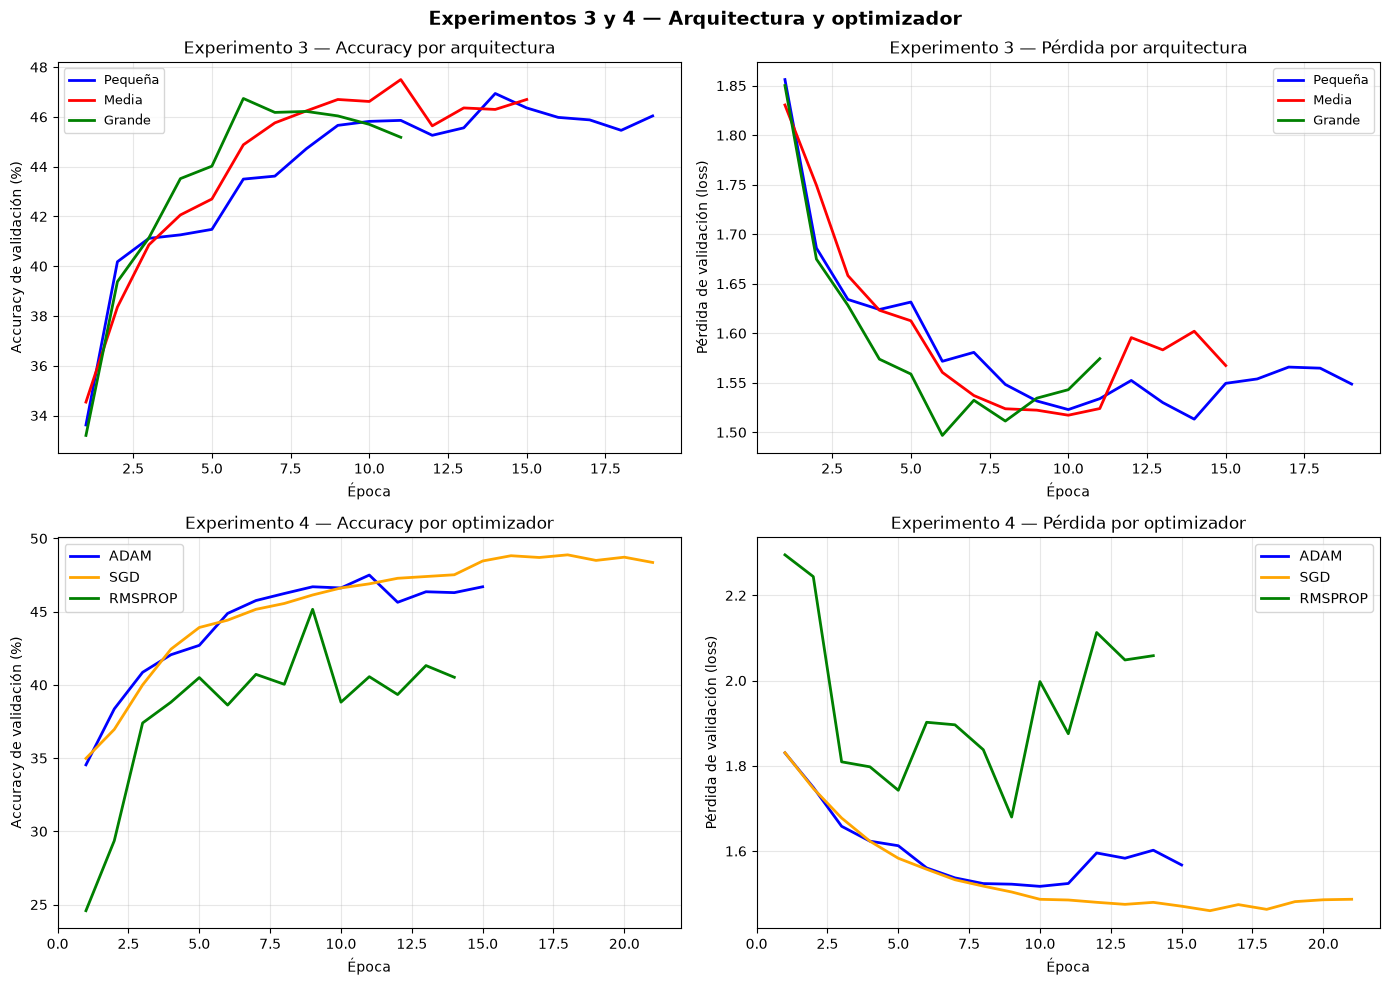


TABLA — ARQUITECTURAS (VALIDACIÓN)
         Arquitectura  Mejor época Train Accuracy Val Accuracy Train Loss Val Loss  Épocas ejecutadas
 Pequeña (256-128-64)           14         52.61%       46.94%     1.3264   1.5133                 19
  Media (512-256-128)           10         52.11%       46.62%     1.3361   1.5172                 15
Grande (1024-512-256)            6         48.29%       46.74%     1.4469   1.4968                 11

TABLA — OPTIMIZADORES (VALIDACIÓN)
Optimizador  Mejor época Train Accuracy Val Accuracy Train Loss Val Loss  Épocas ejecutadas
       ADAM           10         52.11%       46.62%     1.3361   1.5172                 15
        SGD           16         55.61%       48.82%     1.2544   1.4601                 21
    RMSPROP            9         49.49%       45.16%     1.4226   1.6799                 14


In [28]:
print("\nEXPERIMENTO 4 — OPTIMIZADOR")
print("=" * 55)

optimizadores = ["adam", "sgd", "rmsprop"]

hist_opt = {}
res_opt = {}
modelos_opt = {}

for optimizador in optimizadores:
    nombre = optimizador.upper()
    print(f"\nEntrenando con {nombre}")

    # Mantiene comparable la inicialización.
    tf.keras.utils.set_random_seed(42)

    modelo_opt = construir_modelo_experimento(
        neuronas=(512, 256, 128),
        learning_rate=0.001,
        optimizador=optimizador
    )

    historial_opt, resultado_opt = entrenar_experimento(
        modelo_opt,
        nombre=nombre,
        batch_size=64,
        epochs=30
    )

    hist_opt[nombre] = historial_opt
    res_opt[nombre] = resultado_opt
    modelos_opt[nombre] = modelo_opt


# Gráficos de validación de los experimentos 3 y 4.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    "Experimentos 3 y 4 — Arquitectura y optimizador",
    fontsize=14,
    fontweight="bold"
)

colores_arq = ["blue", "red", "green"]
colores_opt = {
    "ADAM": "blue",
    "SGD": "orange",
    "RMSPROP": "green"
}

# Experimento 3: accuracy de validación por arquitectura.
for (nombre, historial), color in zip(hist_arq.items(), colores_arq):
    epocas = range(1, len(historial.history["val_accuracy"]) + 1)

    axes[0, 0].plot(
        epocas,
        [valor * 100 for valor in historial.history["val_accuracy"]],
        color=color,
        linewidth=2,
        label=nombre.split("(")[0].strip()
    )

axes[0, 0].set_title("Experimento 3 — Accuracy por arquitectura")
axes[0, 0].set_xlabel("Época")
axes[0, 0].set_ylabel("Accuracy de validación (%)")
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# Experimento 3: pérdida de validación por arquitectura.
for (nombre, historial), color in zip(hist_arq.items(), colores_arq):
    epocas = range(1, len(historial.history["val_loss"]) + 1)

    axes[0, 1].plot(
        epocas,
        historial.history["val_loss"],
        color=color,
        linewidth=2,
        label=nombre.split("(")[0].strip()
    )

axes[0, 1].set_title("Experimento 3 — Pérdida por arquitectura")
axes[0, 1].set_xlabel("Época")
axes[0, 1].set_ylabel("Pérdida de validación (loss)")
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

# Experimento 4: accuracy de validación por optimizador.
for nombre, historial in hist_opt.items():
    epocas = range(1, len(historial.history["val_accuracy"]) + 1)

    axes[1, 0].plot(
        epocas,
        [valor * 100 for valor in historial.history["val_accuracy"]],
        color=colores_opt[nombre],
        linewidth=2,
        label=nombre
    )

axes[1, 0].set_title("Experimento 4 — Accuracy por optimizador")
axes[1, 0].set_xlabel("Época")
axes[1, 0].set_ylabel("Accuracy de validación (%)")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Experimento 4: pérdida de validación por optimizador.
for nombre, historial in hist_opt.items():
    epocas = range(1, len(historial.history["val_loss"]) + 1)

    axes[1, 1].plot(
        epocas,
        historial.history["val_loss"],
        color=colores_opt[nombre],
        linewidth=2,
        label=nombre
    )

axes[1, 1].set_title("Experimento 4 — Pérdida por optimizador")
axes[1, 1].set_xlabel("Época")
axes[1, 1].set_ylabel("Pérdida de validación (loss)")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "experimentos_3_4_arquitectura_optimizador.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()


# Tablas con métricas de validación de la mejor época de cada modelo.
def crear_tabla_validacion(resultados, nombre_columna):
    filas = []

    for nombre, resultado in resultados.items():
        filas.append({
            nombre_columna: nombre,
            "Mejor época": resultado["Mejor época"],
            "Train Accuracy": f'{resultado["Train accuracy"] * 100:.2f}%',
            "Val Accuracy": f'{resultado["Val accuracy"] * 100:.2f}%',
            "Train Loss": f'{resultado["Train loss"]:.4f}',
            "Val Loss": f'{resultado["Val loss"]:.4f}',
            "Épocas ejecutadas": resultado["Épocas ejecutadas"]
        })

    return pd.DataFrame(filas)


df_arq = crear_tabla_validacion(res_arq, "Arquitectura")
df_opt = crear_tabla_validacion(res_opt, "Optimizador")

print("\n" + "=" * 90)
print("TABLA — ARQUITECTURAS (VALIDACIÓN)")
print("=" * 90)
print(df_arq.to_string(index=False))

print("\n" + "=" * 90)
print("TABLA — OPTIMIZADORES (VALIDACIÓN)")
print("=" * 90)
print(df_opt.to_string(index=False))

## 8.3 Análisis de Experimentos Controlados

### Tabla resumen — Todos los experimentos

| Experimento | Configuración | Val Accuracy | Val Loss |
|---|---|---:|---:|
| Learning rate | 0,01 | 35,94 % | 1,7777 |
| Learning rate | 0,001 | 46,62 % | 1,5172 |
| Learning rate | **0,0001** | **50,36 %** | **1,4301** |
| Batch size | 32 | 45,16 % | 1,5637 |
| Batch size | 64 | 46,62 % | 1,5172 |
| Batch size | **128** | **47,42 %** | **1,4825** |
| Arquitectura | Pequeña (256-128-64) | **46,94 %** | 1,5133 |
| Arquitectura | Media (512-256-128) | 46,62 % | 1,5172 |
| Arquitectura | Grande (1024-512-256) | 46,74 % | **1,4968** |
| Optimizador | Adam | 46,62 % | 1,5172 |
| Optimizador | **SGD** | **48,82 %** | **1,4601** |
| Optimizador | RMSprop | 45,16 % | 1,6799 |

### Hallazgos por experimento
#### Experimento 1 — Tasa de aprendizaje
La tasa de aprendizaje de 0,0001 obtuvo el mejor resultado de esta comparación, con 50,36 % de accuracy de validación y 1,4301 de pérdida. La tasa 0,001 alcanzó 46,62 %, mientras que 0,01 obtuvo un resultado menor, de 35,94 %. En estas pruebas, la tasa más baja funcionó mejor. El scheduler estuvo desactivado para esta comparación, por lo que no compensó las diferencias entre tasas.

####  Experimento 2 — Tamaño del batch
El batch de 128 obtuvo el mayor accuracy de validación (47,42 %) y la menor pérdida (1,4825) entre los tamaños probados. Batch 64 quedó en segundo lugar y batch 32 obtuvo el resultado más bajo. Por tanto, batch 128 fue el mejor de esta comparación.

####  Experimento 3 — Arquitectura
La arquitectura pequeña alcanzó el mayor accuracy de validación (46,94 %), mientras que la arquitectura grande obtuvo la menor pérdida (1,4968). Las diferencias fueron pequeñas, así que aumentar el número de neuronas no produjo una mejora clara en accuracy en esta ejecución.

####  Experimento 4 — Optimizador
Con una tasa de aprendizaje de 0,001 y batch 64, SGD obtuvo el mejor resultado de validación entre los optimizadores probados: 48,82 % de accuracy y 1,4601 de pérdida. Adam alcanzó 46,62 % y RMSprop 45,16 %. Esta conclusión corresponde a esos valores concretos de tasa y batch.

### Mejores resultados individuales
| Hiperparámetro | Mejor resultado observado |
|---|---|
| Learning rate | **0,0001** |
| Batch size | **128** |
| Arquitectura | Pequeña por *accuracy*; grande por pérdida |
| Optimizador | **SGD**, probado con tasa 0,001 |

Como los experimentos cambiaron un hiperparámetro a la vez, todavía no se ha probado en conjunto la combinación de los mejores valores individuales. Por eso, no la presentamos como configuración óptima. Antes de la evaluación final, entrenaremos esa combinación candidata y la compararemos en validación. Luego evaluaremos el modelo elegido una sola vez con el conjunto de prueba.

### 8.4 Comparación de funciones de pérdida.


Entrenando con: Entropía cruzada
Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3181 - loss: 1.8818 - val_accuracy: 0.3454 - val_loss: 1.8305
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3905 - loss: 1.6960 - val_accuracy: 0.3836 - val_loss: 1.7494
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4252 - loss: 1.6035 - val_accuracy: 0.4086 - val_loss: 1.6582
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4486 - loss: 1.5404 - val_accuracy: 0.4206 - val_loss: 1.6232
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4646 - loss: 1.4958 - val_accuracy: 0.4270 - val_loss: 1.6126
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4791 - loss: 1.4596 - val_accuracy: 0.4488 - val_loss: 1.5605
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4913 - loss: 1.4224 - val_accuracy: 0.4576 - val_loss: 1.5371
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5039

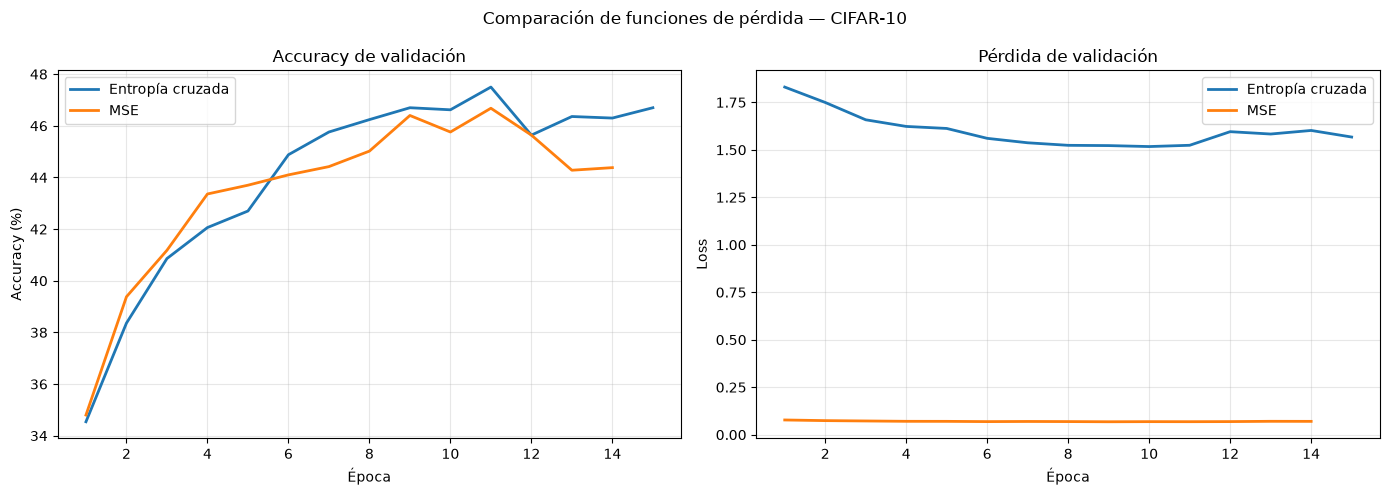

In [29]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# MSE necesita etiquetas one-hot; entropía cruzada dispersa usa etiquetas enteras.
y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_val_onehot = tf.keras.utils.to_categorical(y_val, num_classes=10)

configuraciones_perdida = {
    "Entropía cruzada": {
        "loss": "sparse_categorical_crossentropy",
        "etiquetas_train": y_train,
        "etiquetas_val": y_val,
        "metrica": tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
    },
    "MSE": {
        "loss": "mean_squared_error",
        "etiquetas_train": y_train_onehot,
        "etiquetas_val": y_val_onehot,
        "metrica": tf.keras.metrics.CategoricalAccuracy(name="accuracy"),
    },
}

historiales_perdida = {}
resultados_perdida = {}

for nombre, config in configuraciones_perdida.items():
    print(f"\n{'=' * 55}")
    print(f"Entrenando con: {nombre}")
    print("=" * 55)

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    # Misma arquitectura e hiperparámetros; solo cambia la función de pérdida.
    modelo = models.Sequential([
        layers.Input(shape=(3072,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss=config["loss"],
        metrics=[config["metrica"]],
    )

    parada_temprana = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    )

    historial = modelo.fit(
        x_train,
        config["etiquetas_train"],
        validation_data=(x_val, config["etiquetas_val"]),
        epochs=30,
        batch_size=64,
        callbacks=[parada_temprana],
        verbose=1,
    )

    mejor_indice = int(np.argmin(historial.history["val_loss"]))

    historiales_perdida[nombre] = historial
    resultados_perdida[nombre] = {
        "Mejor época": mejor_indice + 1,
        "Train accuracy": historial.history["accuracy"][mejor_indice],
        "Val accuracy": historial.history["val_accuracy"][mejor_indice],
        "Train loss": historial.history["loss"][mejor_indice],
        "Val loss": historial.history["val_loss"][mejor_indice],
        "Épocas ejecutadas": len(historial.history["accuracy"]),
    }

    print(f"\nMejor época: {mejor_indice + 1}")
    print(f"Accuracy de validación: "
          f"{historial.history['val_accuracy'][mejor_indice] * 100:.2f}%")
    print(f"Pérdida de validación: "
          f"{historial.history['val_loss'][mejor_indice]:.4f}")

# Resumen numérico
print("\nCOMPARACIÓN DE FUNCIONES DE PÉRDIDA")
for nombre, resultado in resultados_perdida.items():
    print(
        f"{nombre}: "
        f"Val accuracy={resultado['Val accuracy'] * 100:.2f}% | "
        f"Val loss={resultado['Val loss']:.4f} | "
        f"Mejor época={resultado['Mejor época']}"
    )

# Gráficos de validación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparación de funciones de pérdida — CIFAR-10")

for nombre, historial in historiales_perdida.items():
    epocas = range(1, len(historial.history["val_accuracy"]) + 1)

    axes[0].plot(
        epocas,
        [a * 100 for a in historial.history["val_accuracy"]],
        linewidth=2,
        label=nombre,
    )
    axes[1].plot(
        epocas,
        historial.history["val_loss"],
        linewidth=2,
        label=nombre,
    )

axes[0].set_title("Accuracy de validación")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title("Pérdida de validación")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("comparacion_funciones_perdida.png", dpi=150, bbox_inches="tight")
plt.show()

Análisis: La entropía cruzada obtuvo un accuracy de validación de 46,62%, ligeramente superior al 46,40% alcanzado con MSE. La diferencia fue de 0,22 puntos porcentuales, por lo que ambos resultados fueron similares en esta ejecución. Los valores de pérdida no se comparan directamente porque cada función usa una escala distinta. Se mantiene la entropía cruzada para la clasificación multiclase.

---
## 9. Evaluación Final del Modelo

### 9.1 Configuración óptima encontrada
| Hiperparámetro | Valor seleccionado | Justificación |
|---|---|---|
| Arquitectura | 512-256-128 | La arquitectura grande no mejoró claramente el accuracy de validación; se conserva la arquitectura media como referencia. |
| Activación | ReLU | Obtuvo el mejor resultado entre ReLU, Sigmoid y Tanh en tu comparación. |
| Batch Normalization | No | En tus pruebas no mejoró la validación. |
| Dropout | No | Dropout al 30% bajó el rendimiento; las variantes de 10% fueron similares, pero no claramente superiores. |
| Learning rate | 0.0001 | Fue el mejor valor probado según accuracy y pérdida de validación en el experimento de learning rate. |
| LR Scheduler | No | Lo evaluarías como una combinación aparte; no lo mezcles con esta configuración sin probarlo junto con los demás valores seleccionados. |
| Batch size | 128 | Obtuvo el mejor resultado de validación entre 32, 64 y 128. |
| Optimizador | SGD | Alcanzó el mayor accuracy de validación entre los optimizadores evaluados. |
| Épocas | Hasta 30, con EarlyStopping | El entrenamiento se detiene si la pérdida de validación deja de mejorar durante 5 épocas. |

### 9.2 ¿Qué miden las métricas?
Como CIFAR-10 tiene 10 clases, Precision, Recall y F1 se calculan para cada clase y luego se resumen con un promedio. Usaremos el promedio macro, que da el mismo peso a cada clase.

| Métrica | Fórmula | ¿Qué mide? |
|---|---|---|
| **Accuracy** | Predicciones correctas / Total de imágenes | Proporción de imágenes clasificadas correctamente. |
| **Precision** | TP / (TP + FP) | De las imágenes asignadas a una clase, cuántas pertenecían realmente a ella. |
| **Recall** | TP / (TP + FN) | De las imágenes que pertenecían a una clase, cuántas detectó el modelo. |
| **F1-score** | 2 · (Precision · Recall) / (Precision + Recall) | Equilibrio entre Precision y Recall. |

TP son verdaderos positivos; FP, falsos positivos; y FN, falsos negativos. En una clasificación multiclase como CIFAR-10, estos valores se interpretan para cada clase antes de calcular el promedio macro.

#### Entrenamiento modelo óptimo

In [30]:
import time
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(42)

# Modelo seleccionado para la evaluación final
modelo_final = models.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

modelo_final.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=0.0001,
        momentum=0.9
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print("=" * 55)
print("MODELO SELECCIONADO — CONFIGURACIÓN FINAL")
print("=" * 55)
modelo_final.summary()

parada_temprana_final = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

print("\nEntrenando el modelo seleccionado...")
inicio = time.time()

historial_final = modelo_final.fit(
    x_train,
    y_train,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=[parada_temprana_final],
    verbose=1,
)

tiempo_final = time.time() - inicio

print(f"\nEntrenamiento completado en {tiempo_final:.1f} segundos")
print(f"Épocas ejecutadas: {len(historial_final.history['accuracy'])}")

mejor_indice = int(
    tf.math.argmin(historial_final.history["val_loss"]).numpy()
)

print(f"Mejor época según val_loss: {mejor_indice + 1}")
print(
    f"Accuracy de validación: "
    f"{historial_final.history['val_accuracy'][mejor_indice] * 100:.2f}%"
)
print(
    f"Pérdida de validación: "
    f"{historial_final.history['val_loss'][mejor_indice]:.4f}"
)

MODELO SELECCIONADO — CONFIGURACIÓN FINAL


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)


Entrenando el modelo seleccionado...
Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1678 - loss: 2.2445 - val_accuracy: 0.2132 - val_loss: 2.1735
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2329 - loss: 2.1375 - val_accuracy: 0.2648 - val_loss: 2.0908
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2711 - loss: 2.0674 - val_accuracy: 0.2954 - val_loss: 2.0312
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2941 - loss: 2.0152 - val_accuracy: 0.3122 - val_loss: 1.9861
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3120 - loss: 1.9745 - val_accuracy: 0.3276 - val_loss: 1.9501
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3234 - loss: 1.9418 - val_accuracy: 0.3376 - val_loss: 1.9212
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3328 - loss: 1.9151 - val_accuracy: 0.3452 - val_loss: 1.8976
Epoch 8/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.

#### Curvas de aprendizaje modelo óptimo

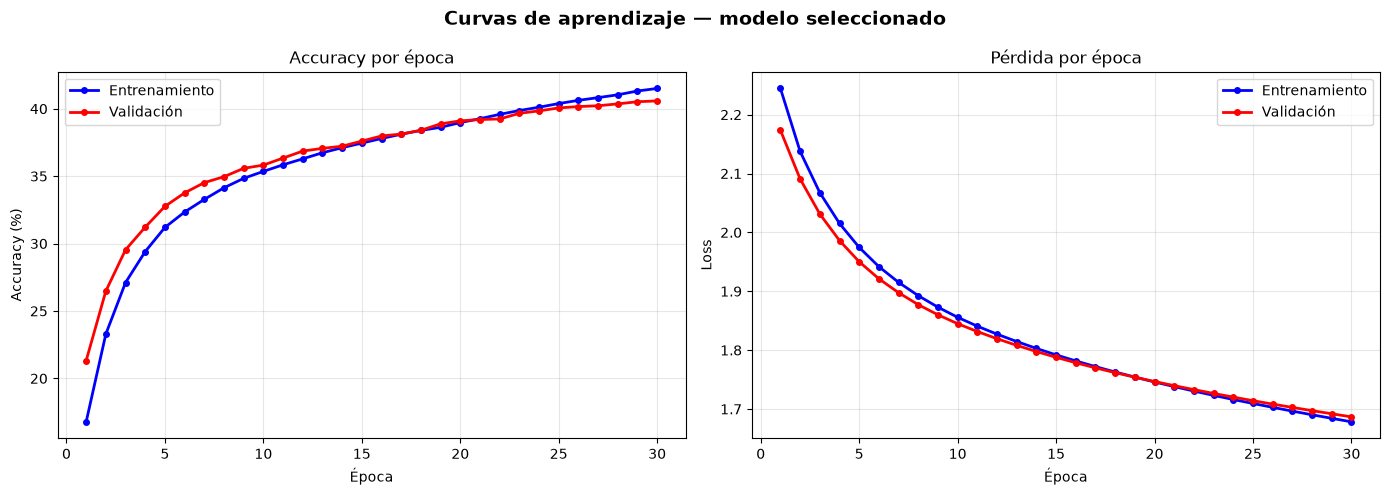

In [31]:
import matplotlib.pyplot as plt

epocas = range(1, len(historial_final.history["accuracy"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Curvas de aprendizaje — modelo seleccionado",
    fontsize=14,
    fontweight="bold",
)

# Accuracy
axes[0].plot(
    epocas,
    [a * 100 for a in historial_final.history["accuracy"]],
    "b-o",
    linewidth=2,
    markersize=4,
    label="Entrenamiento",
)
axes[0].plot(
    epocas,
    [a * 100 for a in historial_final.history["val_accuracy"]],
    "r-o",
    linewidth=2,
    markersize=4,
    label="Validación",
)
axes[0].set_title("Accuracy por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Pérdida
axes[1].plot(
    epocas,
    historial_final.history["loss"],
    "b-o",
    linewidth=2,
    markersize=4,
    label="Entrenamiento",
)
axes[1].plot(
    epocas,
    historial_final.history["val_loss"],
    "r-o",
    linewidth=2,
    markersize=4,
    label="Validación",
)
axes[1].set_title("Pérdida por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("curvas_modelo_seleccionado.png", dpi=150, bbox_inches="tight")
plt.show()

#### Métricas completas

In [32]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

# Predicciones del modelo para las imágenes de prueba.
y_pred_prob = modelo_final.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Asegura que las etiquetas reales tengan formato de vector.
y_test_labels = np.asarray(y_test).reshape(-1)

# Métricas globales: promedio macro, con el mismo peso para cada clase.
acc = accuracy_score(y_test_labels, y_pred)
precision = precision_score(
    y_test_labels, y_pred, average="macro", zero_division=0
)
recall = recall_score(
    y_test_labels, y_pred, average="macro", zero_division=0
)
f1 = f1_score(
    y_test_labels, y_pred, average="macro", zero_division=0
)

print("=" * 55)
print("MÉTRICAS FINALES — MODELO SELECCIONADO")
print("=" * 55)
print(f"Accuracy          : {acc * 100:.2f}%")
print(f"Precision macro   : {precision * 100:.2f}%")
print(f"Recall macro      : {recall * 100:.2f}%")
print(f"F1-score macro    : {f1 * 100:.2f}%")
print("=" * 55)

print("\nReporte detallado por clase:")
print("=" * 65)
print(
    classification_report(
        y_test_labels,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

MÉTRICAS FINALES — MODELO SELECCIONADO
Accuracy          : 40.73%
Precision macro   : 40.19%
Recall macro      : 40.73%
F1-score macro    : 39.94%

Reporte detallado por clase:
              precision    recall  f1-score   support

       Avión     0.4547    0.4520    0.4534      1000
   Automóvil     0.4909    0.4590    0.4744      1000
      Pájaro     0.3048    0.2490    0.2741      1000
        Gato     0.3054    0.2040    0.2446      1000
      Ciervo     0.4274    0.2710    0.3317      1000
       Perro     0.3327    0.3560    0.3440      1000
        Rana     0.4116    0.5050    0.4535      1000
     Caballo     0.4125    0.4740    0.4411      1000
       Barco     0.4501    0.6040    0.5158      1000
      Camión     0.4287    0.4990    0.4612      1000

    accuracy                         0.4073     10000
   macro avg     0.4019    0.4073    0.3994     10000
weighted avg     0.4019    0.4073    0.3994     10000



#### Matriz de confusión

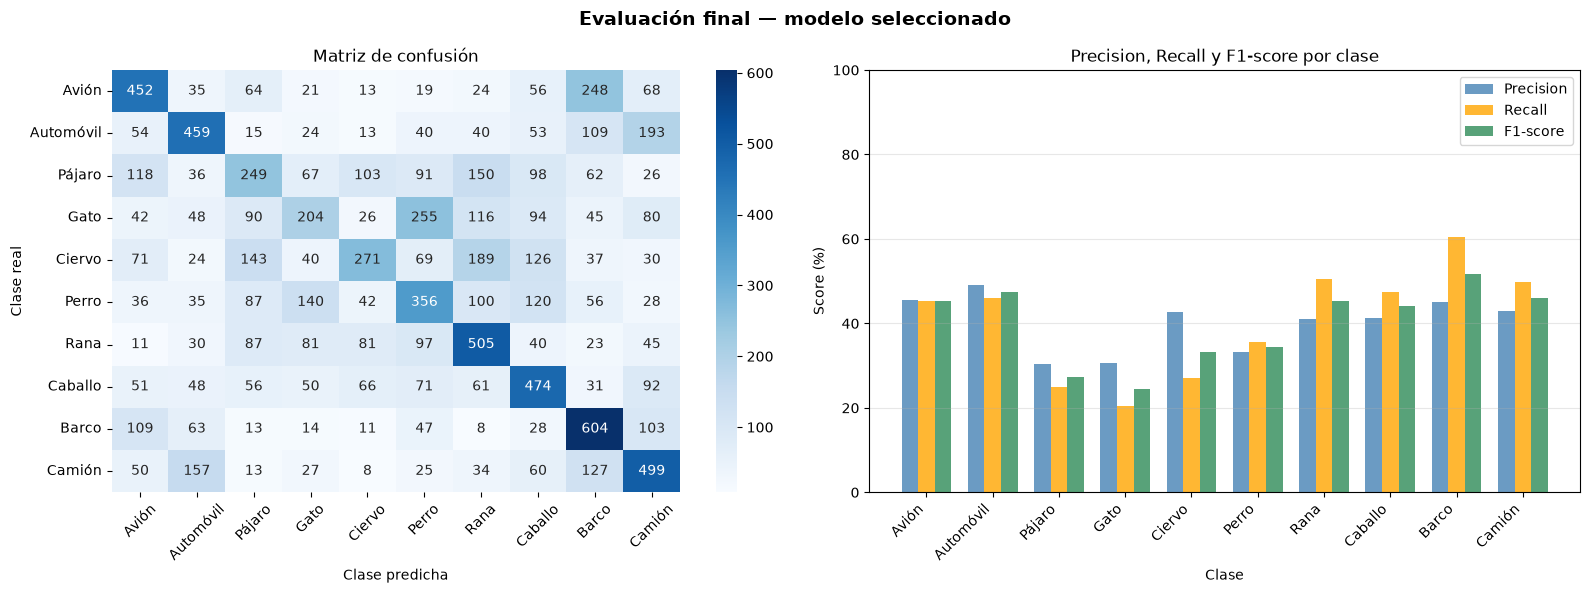

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Matriz de confusión: filas = clase real, columnas = clase predicha.
cm = confusion_matrix(y_test_labels, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Evaluación final — modelo seleccionado", fontsize=14, fontweight="bold")

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0],
)
axes[0].set_title("Matriz de confusión")
axes[0].set_xlabel("Clase predicha")
axes[0].set_ylabel("Clase real")
axes[0].tick_params(axis="x", rotation=45)
axes[0].tick_params(axis="y", rotation=0)

# Métricas individuales para cada clase.
precision_c = precision_score(
    y_test_labels, y_pred, average=None, zero_division=0
)
recall_c = recall_score(
    y_test_labels, y_pred, average=None, zero_division=0
)
f1_c = f1_score(
    y_test_labels, y_pred, average=None, zero_division=0
)

posiciones = np.arange(len(class_names))
ancho = 0.25

axes[1].bar(
    posiciones - ancho,
    precision_c * 100,
    ancho,
    label="Precision",
    color="steelblue",
    alpha=0.8,
)
axes[1].bar(
    posiciones,
    recall_c * 100,
    ancho,
    label="Recall",
    color="orange",
    alpha=0.8,
)
axes[1].bar(
    posiciones + ancho,
    f1_c * 100,
    ancho,
    label="F1-score",
    color="seagreen",
    alpha=0.8,
)

axes[1].set_title("Precision, Recall y F1-score por clase")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Score (%)")
axes[1].set_xticks(posiciones)
axes[1].set_xticklabels(class_names, rotation=45, ha="right")
axes[1].set_ylim(0, 100)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("evaluacion_final_modelo.png", dpi=150, bbox_inches="tight")
plt.show()

#### Cuadro resumen final

In [34]:
import pandas as pd

# Recupera la pérdida del modelo final en el conjunto de prueba.
# La variable `acc` ya contiene su accuracy calculado en la celda anterior.
loss_test_final = modelo_final.evaluate(x_test, y_test, verbose=0)[0]

df_final = pd.DataFrame([
    {
        "Etapa": "Modelo base ReLU",
        "Accuracy validación": "46.62%",
        "Loss validación": "1.5172",
        "Accuracy prueba": "—",
        "Loss prueba": "—",
    },
    {
        "Etapa": "Funciones de activación — mejor: ReLU",
        "Accuracy validación": "46.62%",
        "Loss validación": "1.5172",
        "Accuracy prueba": "—",
        "Loss prueba": "—",
    },
    {
        "Etapa": "Regularización — Dropout 10%",
        "Accuracy validación": "46.90%",
        "Loss validación": "1.4806",
        "Accuracy prueba": "—",
        "Loss prueba": "—",
    },
    {
        "Etapa": "ReduceLROnPlateau",
        "Accuracy validación": "50.46%",
        "Loss validación": "1.4816",
        "Accuracy prueba": "—",
        "Loss prueba": "—",
    },
    {
        "Etapa": "Arquitectura grande (1024-512-256)",
        "Accuracy validación": "46.74%",
        "Loss validación": "1.4968",
        "Accuracy prueba": "—",
        "Loss prueba": "—",
    },
    {
        "Etapa": "Optimizador SGD",
        "Accuracy validación": "48.82%",
        "Loss validación": "1.4601",
        "Accuracy prueba": "—",
        "Loss prueba": "—",
    },
    {
        "Etapa": "Modelo seleccionado final",
        "Accuracy validación": (
            f"{historial_final.history['val_accuracy'][
                int(tf.math.argmin(historial_final.history['val_loss']).numpy())
            ] * 100:.2f}%"
        ),
        "Loss validación": (
            f"{min(historial_final.history['val_loss']):.4f}"
        ),
        "Accuracy prueba": f"{acc * 100:.2f}%",
        "Loss prueba": f"{loss_test_final:.4f}",
    },
])

print("=" * 90)
print("RESUMEN FINAL DE EXPERIMENTOS")
print("=" * 90)
print(df_final.to_string(index=False))
print("=" * 90)

RESUMEN FINAL DE EXPERIMENTOS
                                Etapa Accuracy validación Loss validación Accuracy prueba Loss prueba
                     Modelo base ReLU              46.62%          1.5172               —           —
Funciones de activación — mejor: ReLU              46.62%          1.5172               —           —
         Regularización — Dropout 10%              46.90%          1.4806               —           —
                    ReduceLROnPlateau              50.46%          1.4816               —           —
   Arquitectura grande (1024-512-256)              46.74%          1.4968               —           —
                      Optimizador SGD              48.82%          1.4601               —           —
            Modelo seleccionado final              40.58%          1.6866          40.73%      1.6826


## 9.3 Análisis de Resultados — 
### Métricas Globales
| Métrica | Resultado | Interpretación |
|---|---:|---|
| Accuracy | 40,73% | Clasificó correctamente 4.073 de las 10.000 imágenes de prueba. |
| Precision macro | 40,19% | Promedio de la precisión de las 10 clases, dando el mismo peso a cada una. |
| Recall macro | 40,73% | En promedio, identificó correctamente el 40,73% de las imágenes reales de cada clase. |
| F1-score macro | 39,94% | Promedio del balance entre precision y recall por clase. |

### Resultado por clase
| Clase | Precision | Recall | F1-score | Observación |
|---|---:|---:|---:|---|
| Avión | 45,47% | 45,20% | 45,34% | Desempeño intermedio. |
| Automóvil | 49,09% | 45,90% | 47,44% | Mejor precision entre las clases. |
| Pájaro | 30,48% | 24,90% | 27,41% | Recall bajo. |
| Gato | 30,54% | 20,40% | 24,46% | Clase con menor recall y F1-score. |
| Ciervo | 42,74% | 27,10% | 33,17% | Se detectaron pocos ciervos correctamente. |
| Perro | 33,27% | 35,60% | 34,40% | Desempeño bajo. |
| Rana | 41,16% | 50,50% | 45,35% | Recall relativamente alto. |
| Caballo | 41,25% | 47,40% | 44,11% | Recall superior a su precision. |
| Barco | 45,01% | 60,40% | 51,58% | Mayor recall y mejor F1-score. |
| Camión | 42,87% | 49,90% | 46,12% | Desempeño intermedio. |
### Resultado por clase
El modelo clasificó mejor barcos: reconoció correctamente 604 de 1.000 imágenes. También obtuvo buen recall para ranas (505/1.000). La clase más difícil fue gato, con 204 aciertos de 1.000.
Las confusiones más notorias fueron:
- Los gatos se predijeron como perros 255 veces.
- Los aviones se predijeron como barcos 248 veces.
- Los automóviles se confundieron con camiones 193 veces.
- Los ciervos se confundieron con ranas 189 veces.
- Los camiones se confundieron con automóviles 157 veces.
El modelo es un MLP que recibe las imágenes aplanadas en vectores. Al aplanarlas, pierde la disposición espacial de los píxeles, lo que puede dificultar la distinción entre objetos visualmente parecidos. Una CNN está diseñada para conservar y aprender patrones espaciales.

### Comportamiento del entrenamiento

El modelo terminó las 30 épocas y alcanzó su menor pérdida de validación en la época 30: 1,6866. Las curvas de entrenamiento y validación siguen mejorando y permanecen próximas; no muestran una separación marcada que indique sobreajuste. Esto sugiere que el modelo aún no había terminado de aprender.

### Comparación con los experimentos anteriores
| Experimento | Accuracy de validación |
|---|---:|
| Modelo base ReLU | 46,62% |
| Dropout 10% | 46,90% |
| ReduceLROnPlateau | 50,46% |
| Arquitectura grande | 46,74% |
| SGD probado por separado | 48,82% |
| Modelo final combinado | 40,58% |

Conclusión: el modelo final obtuvo 40,73% de accuracy en prueba, pero la combinación seleccionada no superó los experimentos individuales. Los resultados anteriores de la tabla son de validación y el del modelo final incluye además la prueba, así que no deben presentarse como una comparación directa entre conjuntos. Para un siguiente intento, conviene probar juntas las configuraciones en una validación y verificar con prueba solo la configuración elegida.


---
## 10. Conclusiones y Reflexiones Finales

### 10.1 Resumen del Proyecto

En este proyecto se implementó una red neuronal multicapa (MLP) para clasificar imágenes del conjunto CIFAR-10 en 10 categorías. Se prepararon los datos, se entrenaron modelos con distintas funciones de activación y técnicas de regularización, y se experimentó con hiperparámetros y funciones de pérdida.
La arquitectura final tuvo tres capas ocultas de 512, 256 y 128 neuronas, con activación ReLU, y una salida Softmax de 10 clases. El modelo contó con 1.738.890 parámetros entrenables.



### 10.2 Logros obtenidos
| Experimento | Resultado de validación |
|---|---:|
| Modelo base con ReLU | 46,62% accuracy |
| Mejor función de activación: ReLU | 46,62% accuracy |
| Dropout 10% | 46,90% accuracy |
| ReduceLROnPlateau | 50,46% accuracy |
| Arquitectura grande (1024-512-256) | 46,74% accuracy |
| Optimizador SGD, probado por separado | 48,82% accuracy |
| Modelo final combinado | 40,58% accuracy |

El modelo final obtuvo 40,73% de accuracy en el conjunto de prueba, con precision macro de 40,19%, recall macro de 40,73% y F1-score macro de 39,94%.

Los experimentos anteriores de la tabla corresponden a validación. Como no se evaluaron en el conjunto de prueba, no es posible comparar directamente sus resultados con el 40,73% del modelo final.

### 10.3 Conclusiones por área


**Funciones de activación**

ReLU obtuvo el mayor accuracy de validación, con 46,62%. Sigmoid alcanzó 45,72% y Tanh 34,54%. En estas pruebas, ReLU fue la mejor de las tres funciones evaluadas. La diferencia con Sigmoid fue pequeña, mientras que Tanh rindió claramente menos.

**Regularización**

Dropout al 10% obtuvo resultados similares al modelo sin regularización: 46,90% frente a 46,62% de accuracy de validación. Dropout al 30% quedó por debajo, con 39,54%. Batch Normalization tampoco mejoró los resultados en las configuraciones probadas.
Estos experimentos muestran que aumentar la regularización no mejoró necesariamente el desempeño de este MLP.

**Hiperparámetros y scheduler**

Entre los experimentos informados, ReduceLROnPlateau alcanzó el mayor accuracy de validación, con 50,46%. Batch size 128 obtuvo 47,42%. SGD llegó a 48,82% cuando se probó por separado, usando su configuración experimental.
La arquitectura grande no superó claramente a las otras arquitecturas: obtuvo 46,74% de accuracy de validación, mientras que la pequeña llegó a 46,94%. Por lo tanto, en estas pruebas no se observó que aumentar el número de neuronas garantizara un mejor accuracy.

**Función de pérdida**

La entropía cruzada obtuvo 46,62% de accuracy de validación y MSE obtuvo 46,40%. La diferencia fue pequeña, por lo que ambas configuraciones dieron resultados parecidos en esta ejecución. Sus valores de pérdida no se comparan directamente porque las funciones utilizan escalas distintas.

**Evaluación por clase**

Barco fue la clase con mayor F1-score (51,58%) y recall (60,40%). Gato fue la clase más difícil, con un F1-score de 24,46% y recall de 20,40%. La matriz de confusión muestra que el modelo confundió gatos con perros 255 veces, aviones con barcos 248 veces y automóviles con camiones 193 veces.

**Resultado del modelo final**

El modelo final combinado alcanzó 40,73% de accuracy en prueba. Su accuracy de validación fue 40,58%, y las curvas seguían mejorando al terminar las 30 épocas. La configuración final combinó valores elegidos en experimentos separados; no se había probado como combinación antes. Por eso, sus resultados muestran que el mejor valor individual de cada experimento no necesariamente produce la mejor configuración conjunta.

### 10.4 Limitaciones del MLP

| Limitación | Efecto posible |
|---|---|
| Las imágenes se aplanan en vectores | Se pierde la disposición espacial de los píxeles y la información de vecindad. |
| El modelo aprende con píxeles como características individuales | Puede costarle reconocer patrones visuales como bordes, formas o partes de objetos. |
| Clases visualmente parecidas | El modelo confunde algunas categorías, como gato y perro o automóvil y camión. |
| Sensibilidad a la configuración de entrenamiento | Cambiar conjuntamente optimizador, learning rate y batch size puede modificar mucho el resultado. |

### 10.5 Posibles mejoras
**Dentro del MLP:**
- Probar conjuntamente las configuraciones usando validación, en vez de combinar automáticamente los mejores valores de experimentos separados.
- Evaluar ReduceLROnPlateau como candidato, ya que fue el resultado más alto de validación informado.
- Ajustar el learning rate específicamente para SGD; en el modelo final se usó 0.0001, aunque SGD se había probado por separado con otra configuración.
- Permitir más épocas cuando las curvas todavía mejoran y utilizar EarlyStopping para detener el entrenamiento si la validación deja de mejorar.
- Repetir las comparaciones con varias semillas para saber si las diferencias se mantienen entre ejecuciones.

**Como cambio de arquitectura:**
- Probar una red convolucional (CNN), que conserva la estructura de las imágenes y aprende patrones locales.
- Explorar aumento de datos para entrenar con variaciones controladas de las imágenes.

### 10.6 Reflexión final
El proyecto permitió aplicar conceptos como MLP, backpropagation, funciones de activación, regularización, optimización y métricas de clasificación. Los resultados mostraron que cada cambio debe evaluarse de forma controlada: una técnica que ayuda en una ejecución no necesariamente mejora todas las combinaciones.

Aunque el modelo final no superó algunos resultados de validación anteriores, el proceso permitió identificar una configuración prometedora —ReduceLROnPlateau— y reconocer una limitación importante del experimento final: los hiperparámetros seleccionados por separado no se habían validado juntos. Esa observación sirve para orientar los siguientes experimentos y presentar las conclusiones de manera transparente.

El modelo final obtuvo 40,73% de accuracy en prueba. Las curvas todavía mejoraban al terminar las 30 épocas, así que probaría más épocas con EarlyStopping. También evaluaría ReduceLROnPlateau, que en un experimento separado obtuvo 50,46% en validación, y ajustaría el learning rate específicamente para SGD. Como mejora de arquitectura, probaría una CNN, que conserva la estructura espacial de las imágenes

---
## Extra

Información extra sobre la evaluación.

### 1.0 datos y preprocesamiento.

**Dataset: CIFAR-10 de Keras (tf.keras.datasets.cifar10.load_data()).**

**Clases (10 categorías):** Avión (0), Automóvil (1), Pájaro (2), Gato (3), Ciervo (4), Perro (5), Rana (6), Caballo (7), Barco (8), Camión (9).


**Tamaños de conjuntos (Verificados en Celda 18):**

- Entrenamiento: 40.000 imágenes (80% del conjunto de entrenamiento original de Keras).
- Validación: 10.000 imágenes (20% separado con train_test_split, random_state=42).
- Prueba: 10.000 imágenes (conjunto reservado original de Keras).
- Aclaración: La división real en el notebook es 40k / 10k / 10k, no 45k / 5k.
- Normalización: División de píxeles por 255.0 para escalar valores del rango $[0, 255]$ a $[0.0, 1.0]$.


**Formato de etiquetas:**

- **Entrenamiento general y modelo final:** Vector 1D de enteros ($0$ a $9$) procesados con sparse_categorical_crossentropy.

- **Experimento comparativo de función de pérdida (Celda 109):** Conversión One-Hot (to_categorical) para evaluar categorical_crossentropy frente a mean_squared_error (MSE).

**Forma de entrada al modelo:** Vector aplanado 1D de 3.072 elementos ($32 \times 32 \times 3$).




### 2.0 Modelo Final (Verificado en Celda 115)

- **Arquitectura exacta:** Flatten(3072) $\rightarrow$ Dense(512, activation='relu') $\rightarrow$ Dense(256, activation='relu') $\rightarrow$ Dense(128, activation='relu') $\rightarrow$ Dense(10, activation='softmax').

- **Función de activación oculta:** ReLU.

- **Función de salida:** Softmax (10 neuronas).

- **Función de pérdida:** sparse_categorical_crossentropy.

- **Optimizador:** SGD con learning_rate=0.0001 y momentum=0.9.

- **Tamaño de batch:** 128.

- **Regularización en modelo final:** Sin Dropout (dropout_rate=0.0), Sin Batch Normalization, Sin L2.

- **Scheduler en modelo final:** Sin ReduceLROnPlateau.

- **Épocas:** Máximo 30 épocas con EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True). Completó las 30 épocas (mínimo alcanzado en la época 30).

- **Parámetros totales entrenables:** 1.738.890.



### 3.0 Experimentos (Resultados de validación en NOTEBOOK)

Valores de validación extraídos directamente de las celdas de salida guardadas:


| Experimento | Variante probada | Mejor época | Val Accuracy | Val Loss | Ubicación |
|---|---|---:|---:|---:|---|
| Base inicial | ReLU + Adam (LR 0.001, Batch 64) | 10 | 46,62% | 1,5172 | Celdas 37, 72, 94 |
| Activaciones | **ReLU** | 10 | **46,62%** | **1,5172** | Celdas 69, 72 |
|  | Sigmoide | 27 | 45,72% | 1,5319 | Celdas 69, 72 |
|  | Tanh | 8 | 34,54% | 1,8142 | Celdas 69, 72 |
| Pérdida | **Categorical Crossentropy** | 10 | **46,62%** | **1,5172** | Celdas 109, 110 |
|  | MSE (Mean Squared Error) | 10 | 46,40% | 0,0723 | Celdas 109, 110 |
| Regularización | Sin regularización | 10 | 46,62% | 1,5172 | Celdas 83, 94 |
|  | **Dropout 10%** | 18 | **46,90%** | **1,4806** | Celdas 83, 94 |
|  | Dropout 30% | 18 | 39,54% | 1,7026 | Celdas 83, 94 |
|  | Solo L2 (0.001) | 7 | 46,40% | 1,5629 | Celdas 83, 94 |
|  | Dropout 10% + L2 | 18 | 46,60% | 1,5492 | Celdas 83, 94 |
| Avanzados | Batch Normalization | 4 | 43,88% | 1,5992 | Celdas 91, 94 |
|  | **ReduceLROnPlateau (sin BN)** | 25 | **50,46%** | **1,4816** | Celdas 91, 94 |
|  | BN + ReduceLROnPlateau | 4 | 43,88% | 1,5992 | Celdas 91, 94 |
| Learning Rate | LR = 0.01 | 4 | 35,94% | 1,7777 | Celdas 100, 107 |
|  | LR = 0.001 | 10 | 46,62% | 1,5172 | Celdas 100, 107 |
|  | **LR = 0.0001** | 18 | **50,36%** | **1,4301** | Celdas 100, 107 |
| Batch Size | Batch = 32 | 10 | 45,16% | 1,5637 | Celdas 102, 107 |
|  | Batch = 64 | 10 | 46,62% | 1,5172 | Celdas 102, 107 |
|  | **Batch = 128** | 11 | **47,42%** | **1,4825** | Celdas 102, 107 |
| Arquitectura | **Pequeña (256-128-64)** | 14 | **46,94%** | 1,5133 | Celdas 104, 107 |
|  | Media (512-256-128) | 10 | 46,62% | 1,5172 | Celdas 104, 107 |
|  | Grande (1024-512-256) | 10 | 46,74% | **1,4968** | Celdas 104, 107 |
| Optimizador | Adam | 10 | 46,62% | 1,5172 | Celdas 106, 107 |
|  | **SGD (con LR 0.001)** | 16 | **48,82%** | **1,4601** | Celdas 106, 107 |
|  | RMSprop | 9 | 45,16% | 1,6799 | Celdas 106, 107 |

### 4.0 Evaluación Final

**Métricas Globales del Modelo Final:**
- Accuracy de Validación: 40,58% (Val Loss: 1,6866 en Época 30).
- Accuracy de Prueba: 40,73% (Test Loss: 1,6826).
- Precision Macro: 40,19%.
- Recall Macro: 40,73%.
- F1-Score Macro: 39,94%.


**Resultados por Clase (Prueba - 1.000 imágenes por clase):**
- Avión: Precision 45,47% | Recall 45,20% | F1 45,34% (452 aciertos).
- Automóvil: Precision 49,09% | Recall 45,90% | F1 47,44% (459 aciertos).
- Pájaro: Precision 30,48% | Recall 24,90% | F1 27,41% (249 aciertos).
- Gato: Precision 30,54% | Recall 20,40% | F1 24,46% (204 aciertos - peor desempeño).
- Ciervo: Precision 42,74% | Recall 27,10% | F1 33,17% (271 aciertos).
- Perro: Precision 33,27% | Recall 35,60% | F1 34,40% (356 aciertos).
- Rana: Precision 41,16% | Recall 50,50% | F1 45,35% (505 aciertos).
- Caballo: Precision 41,25% | Recall 47,40% | F1 44,11% (474 aciertos).
- Barco: Precision 45,01% | Recall 60,40% | F1 51,58% (604 aciertos - mejor desempeño).
- Camión: Precision 42,87% | Recall 49,90% | F1 46,12% (499 aciertos).


**Confusiones Principales en Matriz de Confusión:**
- Gatos predichos como Perros: 255 veces.
- Aviones predichos como Barcos: 248 veces.
- Automóviles confundidos con Camiones: 193 veces.
- Ciervos confundidos con Ranas: 189 veces.
- Camiones confundidos con Automóviles: 157 veces.



### 5.0 Cómo mejorar el modelo?

#### 5.1 **Dentro del modelo MLP actual**

**Validación conjunta de hiperparámetros:** Probar las combinaciones juntas (búsqueda en grilla / Grid Search) en vez de unir a ciegas los ganadores de experimentos aislados.

**Corregir la tasa de aprendizaje y reactivar el Scheduler:** Aumentar el learning rate de SGD (ej. de 0.0001 a 0.001 o 0.01) y reincorporar ReduceLROnPlateau (que logró el pico de 50,46% en validación).

**Entrenar por más épocas:** Aumentar el límite de épocas y la paciencia del EarlyStopping, ya que en la época 30 el modelo aún no se había sobreajustado y seguía aprendiendo.

**Aumento de datos (Data Augmentation):** Aplicar giros horizontales y pequeñas translaciones para que la red aprenda variaciones de las imágenes.

#### 5.2 **Mejora definitiva (Arquitectura)**

**Migrar a una Red Convolucional (CNN):** Es el cambio más importante. Al aplanar la imagen a 1D, el MLP pierde la estructura espacial (por eso confunde gatos con perros o aviones con barcos). Una CNN procesa la imagen en 2D, extrae bordes, formas y texturas locales, y supera holgadamente el techo técnico del MLP en visión por computadora.


